# Trivago Recommender System – Model Development and Evaluation

This notebook follows the following framework:

1. Training and evaluating base models with 'train' and 'evaluate' datasets: Classical ML - Logistic Regression, LightGBM with LambdaRank; Deep learning - Dense Neural Network / MLP, Wide & Deep Neural Network
2. Hyperparameter tuning for the best performing models in each category
3. Final evaluating on the untouched 'test' dataset for all 4 models and the Trivago's existing ranking in the original dataset
  - Bias check on the MLP model

4. Interoperability using coefficients in LR and SHAP in MLP
5. Presentation demonstration: tuned MLP ranking one test event

The models are trained using the features and preprocessing strategies defined during the EDA and preprocessing stages. Their performance is subsequently compared using consistent evaluation metrics.

## 1. Training and evaluating base models

In [ ]:
from pathlib import Path

# All project files are stored in the same directory as this notebook
DATA_PATH = Path(".")
OUTPUT_PATH.mkdir(exist_ok=True)
CHECKPOINT_PATH.mkdir(exist_ok=True)

RANDOM_STATE = 42

Mounted at /content/drive


In [ ]:
#Load last preprocesssing checkpoint

train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

val_data = pd.read_parquet(
    f"{DATA_PATH}/val_preprocessed.parquet"
)

test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

print("Training data:", train_data.shape)
print("Validation data:", val_data.shape)
print("Test data:", test_data.shape)

print("\nSessions:")
print("Training:", train_data["session_id"].nunique())
print("Validation:", val_data["session_id"].nunique())
print("Test:", test_data["session_id"].nunique())

print("\nRanking events:")
print("Training:", train_data["ranking_event_id"].nunique())
print("Validation:", val_data["ranking_event_id"].nunique())
print("Test:", test_data["ranking_event_id"].nunique())

Training data: (2539550, 34)
Validation data: (543270, 34)
Test data: (531310, 34)

Sessions:
Training: 57849
Validation: 12396
Test: 12397

Ranking events:
Training: 110716
Validation: 23737
Test: 23273


### 1.1 Logistic Regression

Logistic Regression is used as the classical baseline model. It predicts the probability of a candidate being clicked independently, with the resulting probabilities used as relevance scores for ranking candidates within each candidate group.

In [ ]:
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier

In [ ]:
# Recreate preprocessing defined in the preprocessing notebook for a new run

behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

price_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

city_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

lr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "price",
            price_pipeline,
            ["candidate_price"]
        ),
        (
            "relative_price",
            StandardScaler(),
            ["relative_price"]
        ),
        (
            "filter_match",
            "passthrough",
            ["filter_match"]
        ),
        (
            "city",
            city_pipeline,
            ["city_lr"]
        ),
        (
            "platform_device",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["platform", "device"]
        ),
        (
            "behaviour",
            StandardScaler(),
            behavioural_features
        )
    ]
)

In [ ]:
# Define the model's input

lr_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

X_train_lr = train_data[lr_features]
X_val_lr = val_data[lr_features]
X_test_lr = test_data[lr_features]

y_train = train_data["clicked"]
y_val = val_data["clicked"]
y_test = test_data["clicked"]

print("LR predictors:", len(lr_features))
print("Training:", X_train_lr.shape)
print("Validation:", X_val_lr.shape)
print("Test:", X_test_lr.shape)

LR predictors: 15
Training: (2539550, 15)
Validation: (543270, 15)
Test: (531310, 15)


In [ ]:
# Create the Logistic Regression pipeline using stochastic gradient descent

lr_model = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("model", SGDClassifier(
        loss="log_loss",
        class_weight="balanced",
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

In [ ]:
# Fit model

lr_model.fit(X_train_lr, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [ ]:
# Predict probability of click for each validation candidate

lr_val_scores = lr_model.predict_proba(X_val_lr)[:, 1]

# Sanity check that results make sense

print("Predictions generated:", len(lr_val_scores))
print("Minimum score:", lr_val_scores.min())
print("Maximum score:", lr_val_scores.max())
print("Mean score:", lr_val_scores.mean())

Predictions generated: 543270
Minimum score: 1.91650702163919e-05
Maximum score: 0.9831885844100173
Mean score: 0.5022223210277592


In [ ]:
# Create a separate DF for ranking eval, to keep the val_data unchanged

lr_results = val_data[
    ["ranking_event_id", "candidate_id", "candidate_position", "clicked"]
].copy()

lr_results["predicted_score"] = lr_val_scores

lr_results.head()

,ranking_event_id,candidate_id,candidate_position,clicked,predicted_score
0,0005fe7961566_1,46850,1,0,0.481128
1,0005fe7961566_1,47141,2,1,0.486178
2,0005fe7961566_1,46985,3,0,0.505711
3,0005fe7961566_1,1321090,4,0,0.426383
4,0005fe7961566_1,18456,5,0,0.503707


In [ ]:
# Inspect one candidate group

example_event = lr_results["ranking_event_id"].iloc[0]

example_group = (
    lr_results[
        lr_results["ranking_event_id"] == example_event
    ]
    .sort_values("predicted_score", ascending=False)
    .reset_index(drop=True)
)

example_group["predicted_rank"] = (
    example_group.index + 1
)

example_group

,ranking_event_id,candidate_id,candidate_position,clicked,predicted_score,predicted_rank
0,0005fe7961566_1,98769,12,0,0.526842,1
1,0005fe7961566_1,47012,15,0,0.509179,2
2,0005fe7961566_1,46314,8,0,0.507078,3
3,0005fe7961566_1,46845,24,0,0.506392,4
4,0005fe7961566_1,46985,3,0,0.505711,5
5,0005fe7961566_1,18456,5,0,0.503707,6
6,0005fe7961566_1,47141,2,1,0.486178,7
7,0005fe7961566_1,970119,20,0,0.484118,8
8,0005fe7961566_1,46850,1,0,0.481128,9
9,0005fe7961566_1,47158,21,0,0.476382,10


In [ ]:
# Rank candidates within each candidate group by predicted score

lr_results["predicted_rank"] = (
    lr_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)

clicked_ranks = lr_results.loc[
    lr_results["clicked"] == 1,
    "predicted_rank"
]

lr_mrr = (1 / clicked_ranks).mean() # Calculate Mean Reciprocal Rank

print("Candidate groups evaluated:", len(clicked_ranks))
print("Logistic Regression MRR:", lr_mrr)

Candidate groups evaluated: 23737
Logistic Regression MRR: 0.2520572742546106


In [ ]:
# Calculate Hit Rate@1

lr_hit_rate_1 = (clicked_ranks == 1).mean()

print("Logistic Regression Hit Rate@1:", lr_hit_rate_1)
print(
    "Percentage of clicked candidates ranked first:",
    f"{lr_hit_rate_1:.2%}"
)

Logistic Regression Hit Rate@1: 0.11168218393225765
Percentage of clicked candidates ranked first: 11.17%


In [ ]:
# Check Hit Rate@1 for Trivago's original candidate ordering as a benchmark

trivago_clicked_positions = lr_results.loc[
    lr_results["clicked"] == 1,
    "candidate_position"
]

trivago_hit_rate_1 = (trivago_clicked_positions == 1).mean()

print("Trivago Hit Rate@1:", trivago_hit_rate_1)
print(
    "Percentage of clicked candidates originally ranked first:",
    f"{trivago_hit_rate_1:.2%}"
)

Trivago Hit Rate@1: 0.3174790411593714
Percentage of clicked candidates originally ranked first: 31.75%


In [ ]:
# Check MRR for Trivago's original ranking

trivago_mrr = (1 / trivago_clicked_positions).mean()

print("Candidate groups evaluated:", len(trivago_clicked_positions))
print("Trivago MRR:", trivago_mrr)

Candidate groups evaluated: 23737
Trivago MRR: 0.4583540456245389


In [ ]:
from sklearn.metrics import ndcg_score

In [ ]:
# Calculate NDCG@5 and NDCG@10 from the clicked candidate's predicted rank

def mean_ndcg_at_k(clicked_ranks, k):
    ndcg_scores = np.where(
        clicked_ranks <= k,
        1 / np.log2(clicked_ranks + 1),
        0
    )
    return ndcg_scores.mean()


lr_ndcg_5 = mean_ndcg_at_k(clicked_ranks, 5)
lr_ndcg_10 = mean_ndcg_at_k(clicked_ranks, 10)

print("Logistic Regression NDCG@5:", lr_ndcg_5)
print("Logistic Regression NDCG@10:", lr_ndcg_10)

Logistic Regression NDCG@5: 0.23980899262927802
Logistic Regression NDCG@10: 0.30882196160981285


In [ ]:
# Check NDCG@5 and NDCG@10 for Trivago's original ranking

trivago_ndcg_5 = mean_ndcg_at_k(
    trivago_clicked_positions,
    5
)

trivago_ndcg_10 = mean_ndcg_at_k(
    trivago_clicked_positions,
    10
)

print("Trivago NDCG@5:", trivago_ndcg_5)
print("Trivago NDCG@10:", trivago_ndcg_10)

Trivago NDCG@5: 0.4696073058980494
Trivago NDCG@10: 0.5235687576598941


#### 1.1.2. LR Model evaluation learnings

The Logistic Regression baseline achieved an MRR of 0.252 and HR@1 of 11.17%, compared with an MRR of 0.458 and HR@1 of 31.75% for Trivago's original candidate ordering. This indicates that the baseline learns some ranking signal from the selected features, but does not reproduce or outperform the ranking performance observed in the existing Trivago ordering.

In [ ]:
# Save fitted Logistic Regression checkpoint

import joblib

# Save the complete fitted pipeline (preprocessing + trained SGDClassifier)
joblib.dump(
    lr_model,
    f"{DATA_PATH}/logistic_regression_model.joblib"
)

# Save validation predictions and ranking results
lr_results.to_parquet(
    f"{DATA_PATH}/logistic_regression_validation_results.parquet",
    index=False
)

print(
    "Preprocessor fitted:",
    hasattr(lr_model.named_steps["preprocessor"], "transformers_")
)

print(
    "Estimator fitted:",
    hasattr(lr_model.named_steps["model"], "coef_")
)

print("Logistic Regression checkpoint saved.")

Preprocessor fitted: True
Estimator fitted: True
Logistic Regression checkpoint saved.


### 1.2. LightGBM LambdaRank

In [ ]:
# Define LightGBM features and target

lgbm_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device",
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

X_train_lgbm = train_data[lgbm_features].copy()
X_val_lgbm = val_data[lgbm_features].copy()
X_test_lgbm = test_data[lgbm_features].copy()

y_train_lgbm = train_data["clicked"].copy()
y_val_lgbm = val_data["clicked"].copy()
y_test_lgbm = test_data["clicked"].copy()

train_groups = train_data["ranking_event_id"].copy()
val_groups = val_data["ranking_event_id"].copy()
test_groups = test_data["ranking_event_id"].copy()

print("Training features:", X_train_lgbm.shape)
print("Validation features:", X_val_lgbm.shape)
print("Test features:", X_test_lgbm.shape)

print("Training ranking events:", train_groups.nunique())
print("Validation ranking events:", val_groups.nunique())
print("Test ranking events:", test_groups.nunique())

Training features: (2539550, 15)
Validation features: (543270, 15)
Test features: (531310, 15)
Training ranking events: 110716
Validation ranking events: 23737
Test ranking events: 23273


In [ ]:
# Prepare categorical features for LightGBM

lgbm_categorical_features = [
    "city_lr",
    "platform",
    "device"
]

for feature in lgbm_categorical_features:

    X_train_lgbm[feature] = X_train_lgbm[feature].astype("category")

    train_categories = X_train_lgbm[feature].cat.categories

    X_val_lgbm[feature] = pd.Categorical(
        X_val_lgbm[feature],
        categories=train_categories
    )

    X_test_lgbm[feature] = pd.Categorical(
        X_test_lgbm[feature],
        categories=train_categories
    )

print("Categorical features prepared:", lgbm_categorical_features)

Categorical features prepared: ['city_lr', 'platform', 'device']


In [ ]:
from lightgbm import LGBMRanker

In [ ]:
# Define LightGBM LambdaRank model

lgbm_model = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
# Keep candidates from each ranking event together

train_order = train_groups.sort_values().index
val_order = val_groups.sort_values().index
test_order = test_groups.sort_values().index

X_train_lgbm = X_train_lgbm.loc[train_order].reset_index(drop=True)
y_train_lgbm = y_train_lgbm.loc[train_order].reset_index(drop=True)
train_groups = train_groups.loc[train_order].reset_index(drop=True)

X_val_lgbm = X_val_lgbm.loc[val_order].reset_index(drop=True)
y_val_lgbm = y_val_lgbm.loc[val_order].reset_index(drop=True)
val_groups = val_groups.loc[val_order].reset_index(drop=True)

X_test_lgbm = X_test_lgbm.loc[test_order].reset_index(drop=True)
y_test_lgbm = y_test_lgbm.loc[test_order].reset_index(drop=True)
test_groups = test_groups.loc[test_order].reset_index(drop=True)

train_group_sizes = (
    train_groups
    .groupby(train_groups, sort=False)
    .size()
    .to_numpy()
)

val_group_sizes = (
    val_groups
    .groupby(val_groups, sort=False)
    .size()
    .to_numpy()
)

test_group_sizes = (
    test_groups
    .groupby(test_groups, sort=False)
    .size()
    .to_numpy()
)

print("Training groups:", len(train_group_sizes))
print("Validation groups:", len(val_group_sizes))
print("Test groups:", len(test_group_sizes))

print("Training candidates:", train_group_sizes.sum())
print("Validation candidates:", val_group_sizes.sum())
print("Test candidates:", test_group_sizes.sum())

Training groups: 110716
Validation groups: 23737
Test groups: 23273
Training candidates: 2539550
Validation candidates: 543270
Test candidates: 531310


In [ ]:
import lightgbm as lgb # This gives me access to LightGBM utilities/callbacks

In [ ]:
# Fit LightGBM LambdaRank

lgbm_model.fit(
    X_train_lgbm,
    y_train_lgbm,
    group=train_group_sizes,

    eval_set=[
        (X_val_lgbm, y_val_lgbm)
    ],

    eval_group=[
        val_group_sizes
    ],

    eval_at=[5, 10],

    categorical_feature=[
        "city_lr",
        "platform",
        "device"
    ],

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=20,
            verbose=True
        ),
        lgb.log_evaluation(period=10)
    ]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.636360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5349
[LightGBM] [Info] Number of data points in the train set: 2539550, number of used features: 15
Training until validation scores don't improve for 20 rounds
[10]	valid_0's ndcg@5: 0.215438	valid_0's ndcg@10: 0.285776
[20]	valid_0's ndcg@5: 0.224991	valid_0's ndcg@10: 0.296637
[30]	valid_0's ndcg@5: 0.223589	valid_0's ndcg@10: 0.296316
[40]	valid_0's ndcg@5: 0.223607	valid_0's ndcg@10: 0.296107
Early stopping, best iteration is:
[21]	valid_0's ndcg@5: 0.22512	valid_0's ndcg@10: 0.296776


LGBMRanker(metric='ndcg', n_estimators=500, n_jobs=-1, objective='lambdarank',
           random_state=42)

In [ ]:
# Checkpoint for fitted LightGBM LambdaRank model

import joblib

joblib.dump(
    lgbm_model,
    f"{DATA_PATH}/lightgbm_lambdarank_model.joblib"
)

print("LightGBM model checkpoint saved.")
print("Best iteration:", lgbm_model.best_iteration_)

LightGBM model checkpoint saved.
Best iteration: 21


#### 1.2.2. LightGBM LambdaRank Evaluation

In [ ]:
# Evaluate model

lgbm_val_scores = lgbm_model.predict(X_val_lgbm)

print("Predictions generated:", len(lgbm_val_scores))
print("Minimum score:", lgbm_val_scores.min())
print("Maximum score:", lgbm_val_scores.max())
print("Mean score:", lgbm_val_scores.mean())

Predictions generated: 543270
Minimum score: -1.1468624834072434
Maximum score: 1.1248444159227036
Mean score: -0.017166578356134447


In [ ]:
# Create LambdaRank validation results for ranking evaluation

lgbm_results = pd.DataFrame({
    "ranking_event_id": val_groups,
    "clicked": y_val_lgbm
})

lgbm_results["predicted_score"] = lgbm_val_scores

lgbm_results["predicted_rank"] = (
    lgbm_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)

lgbm_clicked_ranks = lgbm_results.loc[
    lgbm_results["clicked"] == 1,
    "predicted_rank"
]

print("Ranking events evaluated:", len(lgbm_clicked_ranks))

Ranking events evaluated: 23737


In [ ]:
# Calculate ranking metrics for the early-stopped LambdaRank model

lgbm_hit_rate_1 = (lgbm_clicked_ranks == 1).mean()

lgbm_mrr = (1 / lgbm_clicked_ranks).mean()

lgbm_ndcg_5 = mean_ndcg_at_k(
    lgbm_clicked_ranks,
    5
)

lgbm_ndcg_10 = mean_ndcg_at_k(
    lgbm_clicked_ranks,
    10
)

print("Candidate groups evaluated:", len(lgbm_clicked_ranks))
print("LightGBM LambdaRank Hit Rate@1:", f"{lgbm_hit_rate_1:.2%}")
print("LightGBM LambdaRank MRR:", lgbm_mrr)
print("LightGBM LambdaRank NDCG@5:", lgbm_ndcg_5)
print("LightGBM LambdaRank NDCG@10:", lgbm_ndcg_10)

Candidate groups evaluated: 23737
LightGBM LambdaRank Hit Rate@1: 9.81%
LightGBM LambdaRank MRR: 0.2383168828698024
LightGBM LambdaRank NDCG@5: 0.22512019064972355
LightGBM LambdaRank NDCG@10: 0.2967756839321089


#### LightGBM LambdaRank evaluation learnings

The baseline LambdaRank model achieved an HR@1 of 9.81%, MRR of 0.238, NDCG@5 of 0.225, and NDCG@10 of 0.297. Logistic Regression performed slightly better across all four validation metrics. Therefore, for the baseline models, using a ranking-specific objective did not improve ranking performance when both models were provided with the same 15 underlying predictors.

### 1.3. MLP

The two ANN models will be trained using mini-batches, following Géron's recommendation (2025), to improve computational efficiency. PyTorch will be used.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Import and define preprocessing dependencies for the MLP

import numpy as np

from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Behavioural features
behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

# Price preprocessing
price_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

print("MLP preprocessing dependencies ready.")

MLP preprocessing dependencies ready.


In [ ]:
# Create preprocessing for the MLP

mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "price",
            price_pipeline,
            ["candidate_price"]
        ),
        (
            "relative_price",
            StandardScaler(),
            ["relative_price"]
        ),
        (
            "filter_match",
            "passthrough",
            ["filter_match"]
        ),
        (
            "city",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["city_lr"]
        ),
        (
            "platform_device",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["platform", "device"]
        ),
        (
            "behaviour",
            StandardScaler(),
            behavioural_features
        )
    ]
)

In [ ]:
# Fit MLP preprocessing on training data

mlp_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

mlp_preprocessor.fit(
    train_data[mlp_features]
)

print("MLP preprocessor fitted on training data.")

MLP preprocessor fitted on training data.


In [ ]:
# Save current baseline model evaluation metrics before changing to GPU

lr_ndcg_5 = mean_ndcg_at_k(
    clicked_ranks,
    5
)

lr_ndcg_10 = mean_ndcg_at_k(
    clicked_ranks,
    10
)

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM LambdaRank"
    ],
    "HR@1": [
        lr_hit_rate_1,
        lgbm_hit_rate_1
    ],
    "MRR": [
        lr_mrr,
        lgbm_mrr
    ],
    "NDCG@5": [
        lr_ndcg_5,
        lgbm_ndcg_5
    ],
    "NDCG@10": [
        lr_ndcg_10,
        lgbm_ndcg_10
    ]
})

baseline_results.to_csv(
    f"{DATA_PATH}/baseline_model_results.csv",
    index=False
)

baseline_results

,Model,HR@1,MRR,NDCG@5,NDCG@10
0,Logistic Regression,0.111682,0.252057,0.239809,0.308822
1,LightGBM LambdaRank,0.098075,0.238317,0.225120,0.296776


In [ ]:
# Load preprocessed training, validation and test data after switching to GPU

import pandas as pd

train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

val_data = pd.read_parquet(
    f"{DATA_PATH}/val_preprocessed.parquet"
)

test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

print("Training data:", train_data.shape)
print("Validation data:", val_data.shape)
print("Test data:", test_data.shape)

print("Training ranking events:", train_data["ranking_event_id"].nunique())
print("Validation ranking events:", val_data["ranking_event_id"].nunique())
print("Test ranking events:", test_data["ranking_event_id"].nunique())

Training data: (2539550, 34)
Validation data: (543270, 34)
Test data: (531310, 34)
Training ranking events: 110716
Validation ranking events: 23737
Test ranking events: 23273


In [ ]:
# Move following processing to GPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
# Use GPU if available

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Features used by the MLP
mlp_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device",
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

# Check the transformed input dimension
X_sample_mlp = mlp_preprocessor.transform(
    train_data[mlp_features].iloc[:100]
)

mlp_input_dim = X_sample_mlp.shape[1]

print("Device:", device)
print("MLP input features:", mlp_input_dim)
print("Sparse output:", hasattr(X_sample_mlp, "toarray"))

Device: cuda
MLP input features: 5175
Sparse output: True


In [ ]:
# Create the PyTorch dataset

class CandidateDataset(Dataset):
    def __init__(self, data, features, target):
        self.X = data[features].reset_index(drop=True)
        self.y = data[target].reset_index(drop=True)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return idx

In [ ]:
# Mini batch preprocessing

def make_collate_mlp_batch(data):

    def collate_mlp_batch(indices):
        X_batch = data.iloc[indices][mlp_features] # Retrieve raw features for this mini-batch

        X_batch = mlp_preprocessor.transform(X_batch) # Apply the fitted preprocessing

        X_batch = torch.tensor(
            X_batch.toarray(),
            dtype=torch.float32
        )

        # Retrieve target values
        y_batch = torch.tensor(
            data.iloc[indices]["clicked"].values,
            dtype=torch.float32
        ).reshape(-1, 1)

        return X_batch, y_batch

    return collate_mlp_batch

In [ ]:
# Preparing the DataLoader

train_mlp_dataset = CandidateDataset(
    train_data,
    mlp_features,
    "clicked"
)

val_mlp_dataset = CandidateDataset(
    val_data,
    mlp_features,
    "clicked"
)


# Create DataLoaders
train_mlp_loader = DataLoader(
    train_mlp_dataset,
    batch_size=1024,
    shuffle=True,
    collate_fn=make_collate_mlp_batch(train_data)
)

val_mlp_loader = DataLoader(
    val_mlp_dataset,
    batch_size=1024,
    shuffle=False,
    collate_fn=make_collate_mlp_batch(val_data)
)

print("Training candidates:", len(train_mlp_dataset))
print("Training batches:", len(train_mlp_loader))

print("Validation candidates:", len(val_mlp_dataset))
print("Validation batches:", len(val_mlp_loader))

Training candidates: 2539550
Training batches: 2481
Validation candidates: 543270
Validation batches: 531


In [ ]:
# Define configurable MLP

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)

In [ ]:
# Initialise the baseline MLP

mlp_model = MLP(
    input_dim=mlp_input_dim,
    hidden_layers=[128, 64]
).to(device)

print(mlp_model)
print("Model device:", next(mlp_model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=5175, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Model device: cuda:0


In [ ]:
# Define loss function and optimiser

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

print("Loss function and optimiser initialised.")

Loss function and optimiser initialised.


In [ ]:
# Create the MLP training loop

import copy

max_epochs = 20
patience = 2

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < best_val_loss:

        best_val_loss = average_val_loss

        best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            best_model_state,
            f"{DATA_PATH}/mlp_best_model.pt"
        )

        epochs_without_improvement = 0

        print("Best MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore the best-performing model
mlp_model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Epoch 1/20 - Training Loss: 0.184075 - Validation Loss: 0.176757
Best MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.175897 - Validation Loss: 0.176645
Best MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.174614 - Validation Loss: 0.176180
Best MLP checkpoint saved.
Epoch 4/20 - Training Loss: 0.173643 - Validation Loss: 0.177117
Epoch 5/20 - Training Loss: 0.172671 - Validation Loss: 0.176626
Early stopping triggered.
Best validation loss: 0.17618048435213876


In [ ]:
# Save baseline MLP checkpoint

baseline_mlp_checkpoint = {
    "architecture": [128, 64],
    "input_dim": mlp_input_dim,
    "model_state_dict": mlp_model.state_dict(),
    "best_val_loss": best_val_loss,
    "learning_rate": 0.001,
    "batch_size": 1024
}

torch.save(
    baseline_mlp_checkpoint,
    f"{DATA_PATH}/mlp_128_64_checkpoint.pt"
)

print("Baseline MLP checkpoint saved.")
print("Architecture: 128 -> 64")
print("Best validation loss:", best_val_loss)

Baseline MLP checkpoint saved.
Architecture: 128 -> 64
Best validation loss: 0.17618048435213876


In [ ]:
# Generate validation predictions

mlp_model.eval()

mlp_val_scores = []

with torch.no_grad():

    for X_batch, _ in val_mlp_loader:

        X_batch = X_batch.to(device)

        y_logits = mlp_model(X_batch) # Raw model output

        y_prob = torch.sigmoid(y_logits) # Convert logits to probabilities

        mlp_val_scores.extend(
            y_prob.cpu().numpy().flatten()
        )

mlp_val_scores = np.array(mlp_val_scores)

print("Predictions:", len(mlp_val_scores))
print("Min:", mlp_val_scores.min())
print("Max:", mlp_val_scores.max())
print("Mean:", mlp_val_scores.mean())

Predictions: 543270
Min: 0.00018267168
Max: 0.3658015
Mean: 0.04577293


In [ ]:
# Create MLP validation results

mlp_results = val_data[
    ["ranking_event_id", "candidate_id", "candidate_position", "clicked"]
].copy()

mlp_results["predicted_score"] = mlp_val_scores

mlp_results["predicted_rank"] = (
    mlp_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)
mlp_clicked_ranks = mlp_results.loc[
    mlp_results["clicked"] == 1,
    "predicted_rank"
]

print("Candidate groups evaluated:", len(mlp_clicked_ranks))

Candidate groups evaluated: 23737


In [ ]:
# Define NDCG evaluation function

def mean_ndcg_at_k(clicked_ranks, k):
    clicked_ranks = np.asarray(clicked_ranks)

    ndcg_scores = np.where(
        clicked_ranks <= k,
        1 / np.log2(clicked_ranks + 1),
        0
    )

    return ndcg_scores.mean()

#### 1.3.2. MLP Evaluation

In [ ]:
# Calculate ranking metrics for the MLP

mlp_hit_rate_1 = (mlp_clicked_ranks == 1).mean()

mlp_mrr = (1 / mlp_clicked_ranks).mean()

mlp_ndcg_5 = mean_ndcg_at_k(
    mlp_clicked_ranks,
    5
)

mlp_ndcg_10 = mean_ndcg_at_k(
    mlp_clicked_ranks,
    10
)

print("Candidate groups evaluated:", len(mlp_clicked_ranks))
print("MLP Hit Rate@1:", f"{mlp_hit_rate_1:.2%}")
print("MLP MRR:", mlp_mrr)
print("MLP NDCG@5:", mlp_ndcg_5)
print("MLP NDCG@10:", mlp_ndcg_10)

Candidate groups evaluated: 23737
MLP Hit Rate@1: 11.52%
MLP MRR: 0.2581049745273388
MLP NDCG@5: 0.24715193764803728
MLP NDCG@10: 0.31753523672360895


In [ ]:
# Save baseline MLP validation results

mlp_results.to_parquet(
    f"{DATA_PATH}/mlp_128_64_validation_results.parquet",
    index=False
)

mlp_128_64_metrics = pd.DataFrame({
    "Model": ["MLP"],
    "Architecture": ["128 -> 64"],
    "HR@1": [mlp_hit_rate_1],
    "MRR": [mlp_mrr],
    "NDCG@5": [mlp_ndcg_5],
    "NDCG@10": [mlp_ndcg_10],
    "Best validation loss": [best_val_loss]
})

mlp_128_64_metrics.to_csv(
    f"{DATA_PATH}/mlp_128_64_metrics.csv",
    index=False
)

mlp_128_64_metrics

,Model,Architecture,HR@1,MRR,NDCG@5,NDCG@10,Best validation loss
0,MLP,128 -> 64,0.115179,0.258105,0.247152,0.317535,0.17618


These results provide evidence that the MLP's non-linear modelling captures some additional signal compared to LR, but the gain is relatively small. However, the 3 models that were evaluated so far perform worse than the original Trivago baseline ranking. During Finetuning we'll see if this can be improved.

### 1.4. Wide and Deep ANN Architecture

In [ ]:
# Define Wide & Deep feature sets

wide_features = [
    "relative_price",
    "filter_match"
]

deep_features = [
    "candidate_price",
    "city_lr",
    "platform",
    "device",
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

In [ ]:
# Create preprocessing for the Wide & Deep model

wide_preprocessor = ColumnTransformer(
    transformers=[
        (
            "relative_price",
            StandardScaler(),
            ["relative_price"]
        ),
        (
            "filter_match",
            "passthrough",
            ["filter_match"]
        )
    ]
)

deep_preprocessor = ColumnTransformer(
    transformers=[
        (
            "price",
            price_pipeline,
            ["candidate_price"]
        ),
        (
            "city",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["city_lr"]
        ),
        (
            "platform_device",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["platform", "device"]
        ),
        (
            "behaviour",
            StandardScaler(),
            behavioural_features
        )
    ]
)

wide_preprocessor.fit(
    train_data[wide_features]
)

deep_preprocessor.fit(
    train_data[deep_features]
)

print("Wide & Deep preprocessors fitted.")

Wide & Deep preprocessors fitted.


In [ ]:
# Define Wide & Deep mini-batch preprocessing

def preprocess_wide_deep_batch(data, indices):

    batch = data.iloc[indices]

    X_wide = wide_preprocessor.transform(
        batch[wide_features]
    )

    X_deep = deep_preprocessor.transform(
        batch[deep_features]
    )

    return X_wide, X_deep

print("Wide & Deep batch preprocessing function defined.")

Wide & Deep batch preprocessing function defined.


In [ ]:
# Check dimensions

X_wide_sample, X_deep_sample = preprocess_wide_deep_batch(
    train_data,
    list(range(100))
)

print("Wide shape:", X_wide_sample.shape)
print("Deep shape:", X_deep_sample.shape)
print("Deep sparse:", hasattr(X_deep_sample, "toarray"))

Wide shape: (100, 2)
Deep shape: (100, 5173)
Deep sparse: True


In [ ]:
# Create a wide and deep mini batch function

def make_collate_wide_deep_minibatch(data):

    def collate_minibatch(indices):

        # W&D preprocessing
        X_wide, X_deep = preprocess_wide_deep_batch(
            data,
            indices
        )
        X_wide = torch.tensor(
            X_wide,
            dtype=torch.float32
        )
        X_deep = torch.tensor(
            X_deep.toarray(),
            dtype=torch.float32
        )
        y = torch.tensor(
            data.iloc[indices]["clicked"].values,
            dtype=torch.float32
        ).reshape(-1, 1)

        return X_wide, X_deep, y

    return collate_minibatch

In [ ]:
# Create the wide and deep DataLoader

train_wd_dataset = CandidateDataset(
    train_data,
    wide_features + deep_features,
    "clicked"
)

val_wd_dataset = CandidateDataset(
    val_data,
    wide_features + deep_features,
    "clicked"
)

train_wd_loader = DataLoader(
    train_wd_dataset,
    batch_size=1024,
    shuffle=True,
    collate_fn=make_collate_wide_deep_minibatch(train_data)
)

val_wd_loader = DataLoader(
    val_wd_dataset,
    batch_size=1024,
    shuffle=False,
    collate_fn=make_collate_wide_deep_minibatch(val_data)
)

print("Training candidates:", len(train_wd_dataset))
print("Training batches:", len(train_wd_loader))
print("Validation candidates:", len(val_wd_dataset))
print("Validation batches:", len(val_wd_loader))

Training candidates: 2539550
Training batches: 2481
Validation candidates: 543270
Validation batches: 531


In [ ]:
# define the wide and deep model

class WideAndDeep(nn.Module):
    def __init__(self, wide_dim, deep_dim):
        super().__init__()
        self.deep_network = nn.Sequential(
            nn.Linear(deep_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(
            64 + wide_dim,
            1
        )

    def forward(self, X_wide, X_deep):

        deep_output = self.deep_network(X_deep)

        combined = torch.cat(
            [X_wide, deep_output],
            dim=1
        )

        output = self.output_layer(combined)

        return output

In [ ]:
# Initialise the model

wide_dim = X_wide_sample.shape[1]
deep_dim = X_deep_sample.shape[1]

wd_model = WideAndDeep(
    wide_dim=wide_dim,
    deep_dim=deep_dim
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    wd_model.parameters(),
    lr=0.001
)

print("Wide input dimensions:", wide_dim)
print("Deep input dimensions:", deep_dim)
print("Model device:", next(wd_model.parameters()).device)
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Wide input dimensions: 2
Deep input dimensions: 5173
Model device: cuda:0
Loss function: BCEWithLogitsLoss()
Optimizer: Adam


In [ ]:
# Train Wide & Deep with early stopping

import copy

max_epochs = 20
patience = 2

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    wd_model.train()

    train_loss = 0.0

    for X_wide, X_deep, y in train_wd_loader:

        X_wide = X_wide.to(device)
        X_deep = X_deep.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_logits = wd_model(
            X_wide,
            X_deep
        )

        loss = criterion(
            y_logits,
            y
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_wd_loader)

    # Validation
    wd_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_wide, X_deep, y in val_wd_loader:

            X_wide = X_wide.to(device)
            X_deep = X_deep.to(device)
            y = y.to(device)

            y_logits = wd_model(
                X_wide,
                X_deep
            )

            loss = criterion(
                y_logits,
                y
            )

            val_loss += loss.item()

    val_loss /= len(val_wd_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} - "
        f"Training Loss: {train_loss:.6f} - "
        f"Validation Loss: {val_loss:.6f}"
    )

    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            wd_model.state_dict()
        )

        torch.save(
            best_model_state,
            f"{DATA_PATH}/wide_deep_best_model.pt"
        )

        epochs_without_improvement = 0

        print("Best Wide & Deep checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

# Restore best model
wd_model.load_state_dict(
    best_model_state
)

print(
    "Best validation loss:",
    best_val_loss
)

Epoch 1/20 - Training Loss: 0.184673 - Validation Loss: 0.178384
Best Wide & Deep checkpoint saved.
Epoch 2/20 - Training Loss: 0.178352 - Validation Loss: 0.178898
Epoch 3/20 - Training Loss: 0.177249 - Validation Loss: 0.178013
Best Wide & Deep checkpoint saved.
Epoch 4/20 - Training Loss: 0.176474 - Validation Loss: 0.178205
Epoch 5/20 - Training Loss: 0.175856 - Validation Loss: 0.178743
Early stopping triggered.
Best validation loss: 0.17801314788798603


In [ ]:
# Save Wide & Deep baseline checkpoint

wide_deep_checkpoint = {
    "wide_dim": wide_dim,
    "deep_dim": deep_dim,
    "deep_architecture": [128, 64],
    "model_state_dict": wd_model.state_dict(),
    "best_val_loss": best_val_loss,
    "learning_rate": 0.001,
    "batch_size": 1024
}

torch.save(
    wide_deep_checkpoint,
    f"{DATA_PATH}/wide_deep_baseline_checkpoint.pt"
)

print("Wide & Deep baseline checkpoint saved.")
print("Deep architecture: 128 -> 64")
print("Best validation loss:", best_val_loss)

Wide & Deep baseline checkpoint saved.
Deep architecture: 128 -> 64
Best validation loss: 0.17801314788798603


In [ ]:
# Generate wide and deep predictions

wd_model.eval()

wd_val_scores = []

with torch.no_grad():

    for X_wide, X_deep, _ in val_wd_loader:

        X_wide = X_wide.to(device)
        X_deep = X_deep.to(device)

        y_logits = wd_model(
            X_wide,
            X_deep
        )

        y_prob = torch.sigmoid(y_logits)

        wd_val_scores.extend(
            y_prob.cpu().numpy().flatten()
        )

wd_val_scores = np.array(wd_val_scores)

print("Predictions:", len(wd_val_scores))
print("Min:", wd_val_scores.min())
print("Max:", wd_val_scores.max())
print("Mean:", wd_val_scores.mean())

Predictions: 543270
Min: 1.3411338e-07
Max: 0.27885208
Mean: 0.04223636


In [ ]:
# Create wide and deep ranking

wd_results = val_data[
    [
        "ranking_event_id",
        "candidate_id",
        "candidate_position",
        "clicked"
    ]
].copy()

wd_results["predicted_score"] = wd_val_scores

wd_results["predicted_rank"] = (
    wd_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)

wd_clicked_ranks = wd_results.loc[
    wd_results["clicked"] == 1,
    "predicted_rank"
]

print(
    "Candidate groups evaluated:",
    len(wd_clicked_ranks)
)

Candidate groups evaluated: 23737


#### 1.4.2. Wide and Deep Evaluation

In [ ]:
# Evaluate wide and deep predictions

wd_hr1 = (
    wd_clicked_ranks == 1
).mean()

wd_mrr = (
    1 / wd_clicked_ranks
).mean()

wd_ndcg5 = mean_ndcg_at_k(
    wd_clicked_ranks,
    5
)

wd_ndcg10 = mean_ndcg_at_k(
    wd_clicked_ranks,
    10
)

print("Wide & Deep Results")
print("-------------------")
print(f"HR@1: {wd_hr1:.2%}")
print(f"MRR: {wd_mrr}")
print(f"NDCG@5: {wd_ndcg5}")
print(f"NDCG@10: {wd_ndcg10}")

Wide & Deep Results
-------------------
HR@1: 11.14%
MRR: 0.25240827369240865
NDCG@5: 0.24021758020700368
NDCG@10: 0.3105447814506038


In [ ]:
# Save Wide & Deep validation results

wd_results.to_parquet(
    f"{DATA_PATH}/wide_deep_validation_results.parquet",
    index=False
)

wd_metrics = pd.DataFrame({
    "Model": ["Wide & Deep"],
    "Architecture": ["Wide 2 + Deep 128 -> 64"],
    "HR@1": [wd_hr1],
    "MRR": [wd_mrr],
    "NDCG@5": [wd_ndcg5],
    "NDCG@10": [wd_ndcg10],
    "Best validation loss": [best_val_loss]
})

wd_metrics.to_csv(
    f"{DATA_PATH}/wide_deep_metrics.csv",
    index=False
)

wd_metrics

,Model,Architecture,HR@1,MRR,NDCG@5,NDCG@10,Best validation loss
0,Wide & Deep,Wide 2 + Deep 128 -> 64,0.111387,0.252408,0.240218,0.310545,0.178013


**Wide & Deep baseline:** The Wide & Deep model achieved an HR@1 of 11.14%, MRR of 0.252, NDCG@5 of 0.240 and NDCG@10 of 0.311. Performance was lower than the standard MLP across all four ranking metrics, indicating that separating relative price and filter match into a direct wide pathway did not improve ranking performance in the baseline configuration.

### Comparing validation results of all four learned models + the Trivago original ranking

| Ranking | HR@1 | MRR | NDCG@5 | NDCG@10 |
| --- | --: | --: | --: | --: |
| Trivago original ranking | 31.75% | 0.458 | 0.470 | 0.524 |
| **MLP** | **11.52%** | **0.258** | **0.247** | **0.318** |
| Wide & Deep NN | 11.14% | 0.252 | 0.240 | 0.311 |
| Logistic Regression | 11.17% | 0.252 | 0.240 | 0.309 |
| LightGBM LambdaRank | 9.81% | 0.238 | 0.225 | 0.297 |

Among the learned baseline models, the MLP achieved the strongest validation performance across all four ranking metrics. Logistic Regression and Wide & Deep produced very similar results despite their substantially different architectures, while LightGBM LambdaRank produced the lowest ranking metrics.

The original Trivago candidate ordering substantially outperformed all four learned models. This benchmark should be interpreted as the ranking already present in the logged data rather than as a model trained under the same experimental conditions.

Based on the validation results, MLP and Logistic Regression were selected for targeted hyperparameter tuning as the strongest-performing neural and classical models respectively. This enables further comparison between the strongest neural model and a simpler classical baseline, directly supporting the research question of whether improvements from deep learning are sufficient to justify additional model complexity.

## 2. Hyperparameter tuning

### 2.1. Logistic Regression hyperparameter tuning

Targeted tuning will follow a sequential approach, varying one component while carrying the selected validation configuration forward to the next experiment (Géron, 2025).

1. **Regularisation** – compare L1, L2 and Elastic Net regularisation at α = 0.00001, 0.0001 and 0.001. These configurations test different forms and strengths of coefficient regularisation.

2. **SGD learning rate** – using the selected regularisation configuration, test alternative learning-rate settings to assess whether optimisation can be improved while holding the remaining model specification constant.

In [ ]:
# Restore runtime for Logistic Regression tuning

import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier

RANDOM_STATE = 42

# Load modelling datasets
train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

val_data = pd.read_parquet(
    f"{DATA_PATH}/val_preprocessed.parquet"
)

test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Mounted at /content/drive
Train: (2539550, 34)
Validation: (543270, 34)
Test: (531310, 34)


In [ ]:
# Restore Logistic Regression preprocessing

behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

lr_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

price_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

city_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("price", price_pipeline, ["candidate_price"]),
        ("relative_price", StandardScaler(), ["relative_price"]),
        ("filter_match", "passthrough", ["filter_match"]),
        ("city", city_pipeline, ["city_lr"]),
        ("platform_device",
         OneHotEncoder(handle_unknown="ignore", sparse_output=True),
         ["platform", "device"]),
        ("behaviour",
         StandardScaler(),
         behavioural_features)
    ]
)

print("LR predictors:", len(lr_features))
print(lr_features)

LR predictors: 15
['candidate_price', 'relative_price', 'filter_match', 'city_lr', 'platform', 'device', 'count_sort_change', 'count_filter_selection', 'count_item_deals', 'count_item_image', 'count_item_info', 'count_item_rating', 'count_search_destination', 'count_search_item', 'count_search_poi']


In [ ]:
# Tune Logistic Regression regularisation

from sklearn.metrics import log_loss

regularisation_results = []

penalties = ["l1", "l2", "elasticnet"]
alphas = [0.00001, 0.0001, 0.001]

for penalty in penalties:
    for alpha in alphas:

        print(f"\nTraining penalty={penalty}, alpha={alpha}")

        model = Pipeline([
            ("preprocessor", lr_preprocessor),
            ("model", SGDClassifier(
                loss="log_loss",
                penalty=penalty,
                alpha=alpha,
                l1_ratio=0.15 if penalty == "elasticnet" else 0.15,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=RANDOM_STATE
            ))
        ])

        model.fit(
            train_data[lr_features],
            train_data["clicked"]
        )

        val_prob = model.predict_proba(
            val_data[lr_features]
        )[:, 1]

        val_log_loss = log_loss(
            val_data["clicked"],
            val_prob
        )

        regularisation_results.append({
            "penalty": penalty,
            "alpha": alpha,
            "validation_log_loss": val_log_loss
        })

        print("Validation log loss:", val_log_loss)


regularisation_results = pd.DataFrame(
    regularisation_results
).sort_values("validation_log_loss")

regularisation_results


Training penalty=l1, alpha=1e-05
Validation log loss: 0.850462559742866

Training penalty=l1, alpha=0.0001
Validation log loss: 0.8161605530738367

Training penalty=l1, alpha=0.001
Validation log loss: 0.7196639173761809

Training penalty=l2, alpha=1e-05
Validation log loss: 0.69200670252841

Training penalty=l2, alpha=0.0001
Validation log loss: 0.7042950809564416

Training penalty=l2, alpha=0.001
Validation log loss: 0.7063323474718295

Training penalty=elasticnet, alpha=1e-05
Validation log loss: 0.6558733697975423

Training penalty=elasticnet, alpha=0.0001
Validation log loss: 0.6887972255912925

Training penalty=elasticnet, alpha=0.001
Validation log loss: 0.7063912951823776


,penalty,alpha,validation_log_loss
6,elasticnet,0.00001,0.655873
7,elasticnet,0.00010,0.688797
3,l2,0.00001,0.692007
4,l2,0.00010,0.704295
5,l2,0.00100,0.706332
8,elasticnet,0.00100,0.706391
2,l1,0.00100,0.719664
1,l1,0.00010,0.816161
0,l1,0.00001,0.850463


In [ ]:
# Save Logistic Regression regularisation tuning results

regularisation_results.to_csv(
    f"{DATA_PATH}/lr_regularisation_results.csv",
    index=False
)

print("LR regularisation tuning results saved.")

display(regularisation_results)

LR regularisation tuning results saved.


,penalty,alpha,validation_log_loss
6,elasticnet,0.00001,0.655873
7,elasticnet,0.00010,0.688797
3,l2,0.00001,0.692007
4,l2,0.00010,0.704295
5,l2,0.00100,0.706332
8,elasticnet,0.00100,0.706391
2,l1,0.00100,0.719664
1,l1,0.00010,0.816161
0,l1,0.00001,0.850463


In [ ]:
# Create the transformed dataset

lr_preprocessor.fit(train_data[lr_features])

X_train_lr = lr_preprocessor.transform(
    train_data[lr_features]
)

X_val_lr = lr_preprocessor.transform(
    val_data[lr_features]
)

y_train_lr = train_data["clicked"].values
y_val_lr = val_data["clicked"].values

print("Training shape:", X_train_lr.shape)
print("Validation shape:", X_val_lr.shape)
print("Training sparse:", hasattr(X_train_lr, "toarray"))
print("Validation sparse:", hasattr(X_val_lr, "toarray"))

Training shape: (2539550, 5175)
Validation shape: (543270, 5175)
Training sparse: True
Validation sparse: True


In [ ]:
# Checkpoint for transformed Logistic Regression datasets

from scipy.sparse import save_npz

save_npz(
    f"{DATA_PATH}/X_train_lr_transformed.npz",
    X_train_lr
)

save_npz(
    f"{DATA_PATH}/X_val_lr_transformed.npz",
    X_val_lr
)

np.save(
    f"{DATA_PATH}/y_train_lr.npy",
    y_train_lr
)

np.save(
    f"{DATA_PATH}/y_val_lr.npy",
    y_val_lr
)

print("Transformed LR datasets saved.")
print("Training shape:", X_train_lr.shape)
print("Validation shape:", X_val_lr.shape)

Transformed LR datasets saved.
Training shape: (2539550, 5175)
Validation shape: (543270, 5175)


In [ ]:
# Restore NDCG evaluation function

def mean_ndcg_at_k(clicked_ranks, k):

    clicked_ranks = np.asarray(clicked_ranks)

    ndcg = np.where(
        clicked_ranks <= k,
        1 / np.log2(clicked_ranks + 1),
        0
    )

    return ndcg.mean()

print("NDCG evaluation function restored.")

NDCG evaluation function restored.


In [ ]:
# Import timing utility

import time

print("time imported.")

time imported.


In [ ]:
# Optimise learning rate. Best regularisation configuration fixed: penalty="elasticnet", alpha=0.00001, l1_ratio=0.15
# Compare the default "optimal" schedule with alternative inverse-scaling schedules.

learning_rate_configs = [
    {
        "learning_rate": "optimal"
    },
    {
        "learning_rate": "invscaling",
        "eta0": 0.001
    },
    {
        "learning_rate": "invscaling",
        "eta0": 0.01
    },
    {
        "learning_rate": "invscaling",
        "eta0": 0.1
    }
]

lr_learning_rate_models = []

for i, config in enumerate(learning_rate_configs, start=1):

    print(
        f"Training configuration {i}/{len(learning_rate_configs)}: "
        f"{config}"
    )

    model = SGDClassifier(
        loss="log_loss",

        # Best regularisation configuration
        penalty="elasticnet",
        alpha=0.00001,
        l1_ratio=0.15,
        class_weight="balanced",

        # Learning-rate configuration
        **config,

        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE
    )

    start_time = time.time()

    model.fit(
        X_train_lr,
        y_train_lr
    )

    training_time = time.time() - start_time

    lr_learning_rate_models.append({
        "config": config,
        "model": model,
        "training_time": training_time
    })

    print(
        f"Completed in {training_time:.2f} seconds\n"
    )

Training configuration 1/4: {'learning_rate': 'optimal'}
Completed in 31.83 seconds

Training configuration 2/4: {'learning_rate': 'invscaling', 'eta0': 0.001}
Completed in 7.55 seconds

Training configuration 3/4: {'learning_rate': 'invscaling', 'eta0': 0.01}
Completed in 10.63 seconds

Training configuration 4/4: {'learning_rate': 'invscaling', 'eta0': 0.1}
Completed in 7.52 seconds



In [ ]:
# Evaluate Logistic Regression learning-rate configurations

from sklearn.metrics import log_loss

lr_learning_rate_results = []

for result in lr_learning_rate_models:

    config = result["config"]
    model = result["model"]

    val_prob = model.predict_proba(X_val_lr)[:, 1]

    val_log_loss = log_loss(
        y_val_lr,
        val_prob
    )

    lr_learning_rate_results.append({
        **config,
        "validation_log_loss": val_log_loss,
        "training_time": result["training_time"]
    })

lr_learning_rate_results_df = (
    pd.DataFrame(lr_learning_rate_results)
    .sort_values("validation_log_loss")
    .reset_index(drop=True)
)

display(lr_learning_rate_results_df)

,learning_rate,validation_log_loss,training_time,eta0
0,optimal,0.655873,31.825398,NaN
1,invscaling,0.694651,7.551868,0.001
2,invscaling,0.697591,10.632766,0.010
3,invscaling,0.702680,7.518724,0.100


In [ ]:
# Evaluate final tuned Logistic Regression on validation set

final_lr_model = lr_learning_rate_models[0]["model"]

val_scores = final_lr_model.predict_proba(X_val_lr)[:, 1]

lr_tuned_results = val_data[
    [
        "ranking_event_id",
        "candidate_id",
        "clicked"
    ]
].copy()

lr_tuned_results["predicted_score"] = val_scores

lr_tuned_results["predicted_rank"] = (
    lr_tuned_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)

clicked_ranks = lr_tuned_results.loc[
    lr_tuned_results["clicked"] == 1,
    "predicted_rank"
].to_numpy()

# Ranking metrics
lr_hit_rate_1 = (clicked_ranks == 1).mean()
lr_mrr = (1 / clicked_ranks).mean()
lr_ndcg_5 = mean_ndcg_at_k(clicked_ranks, 5)
lr_ndcg_10 = mean_ndcg_at_k(clicked_ranks, 10)

print("Ranking events:", len(clicked_ranks))
print("HR@1:", lr_hit_rate_1)
print("MRR:", lr_mrr)
print("NDCG@5:", lr_ndcg_5)
print("NDCG@10:", lr_ndcg_10)

Ranking events: 23737
HR@1: 0.11176644057800059
MRR: 0.25236266260871887
NDCG@5: 0.24029434033473734
NDCG@10: 0.3092595538249347


In [ ]:
# Save final tuned Logistic Regression model, results and processor

import joblib

joblib.dump(
    final_lr_model,
    f"{DATA_PATH}/logistic_regression_tuned_model.joblib"
)

joblib.dump(
    lr_preprocessor,
    f"{DATA_PATH}/logistic_regression_preprocessor.joblib"
)

lr_tuned_results.to_parquet(
    f"{DATA_PATH}/logistic_regression_tuned_validation_results.parquet",
    index=False
)

tuned_lr_metrics = pd.DataFrame({
    "Model": ["Tuned Logistic Regression"],
    "Penalty": ["elasticnet"],
    "Alpha": [0.00001],
    "L1 ratio": [0.15],
    "Learning rate": ["optimal"],
    "HR@1": [lr_hit_rate_1],
    "MRR": [lr_mrr],
    "NDCG@5": [lr_ndcg_5],
    "NDCG@10": [lr_ndcg_10]
})

tuned_lr_metrics.to_csv(
    f"{DATA_PATH}/logistic_regression_tuned_metrics.csv",
    index=False
)

lr_learning_rate_results_df.to_csv(
    f"{DATA_PATH}/lr_learning_rate_results.csv",
    index=False
)

print("Final tuned Logistic Regression model and results saved.")

Final tuned Logistic Regression model and results saved.


Hyperparameter tuning produced only marginal improvements in Logistic Regression ranking performance. The model remained relatively stable across the stronger-performing configurations, suggesting that further optimisation of these hyperparameters is unlikely to yield substantial gains with the current features and preprocessing.

### 2.2. MLP Hyperparameter tuning
1. Architecture: Tune the model architecture (baseline architecture is: 11,115 → 128 → 64 → 1)
2. Learning rate: experiment with different LRs, with the chosen architecture, and Adam, ReLU and batch size 1024 fixed.
3. Activation function: use the best configuration from the previous experiments and test a different activation function

#### 2.2.1. Architecture tuning

In [ ]:
# Initialise 64 -> 64 MLP architecture experiment

mlp_model = MLP(
    input_dim=mlp_input_dim,
    hidden_layers=[64, 64]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

print(mlp_model)
print("Model device:", next(mlp_model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=5175, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Model device: cuda:0


In [ ]:
# Create train loop for MLP architecture: 64 -> 64

import copy

max_epochs = 20
patience = 2

arch_best_val_loss = float("inf")
arch_best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < arch_best_val_loss:

        arch_best_val_loss = average_val_loss

        arch_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            arch_best_model_state,
            f"{DATA_PATH}/mlp_64_64_checkpoint.pt"
        )

        epochs_without_improvement = 0

        print("Best 64 -> 64 MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore the best-performing model
mlp_model.load_state_dict(arch_best_model_state)

print("Best validation loss:", arch_best_val_loss)

Epoch 1/20 - Training Loss: 0.185844 - Validation Loss: 0.177259
Best 64 -> 64 MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.176245 - Validation Loss: 0.176825
Best 64 -> 64 MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.174916 - Validation Loss: 0.176068
Best 64 -> 64 MLP checkpoint saved.
Epoch 4/20 - Training Loss: 0.173924 - Validation Loss: 0.176168
Epoch 5/20 - Training Loss: 0.173249 - Validation Loss: 0.176425
Early stopping triggered.
Best validation loss: 0.17606792443216185


Given the comparable performance with a smaller architecture, 64 → 64 was retained as the layer width for the subsequent deeper architecture experiment.

In [ ]:
# Train MLP architecture: 64 -> 64 -> 64

import copy

max_epochs = 20
patience = 2

arch_best_val_loss = float("inf")
arch_best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < arch_best_val_loss:

        arch_best_val_loss = average_val_loss

        arch_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            arch_best_model_state,
            f"{DATA_PATH}/mlp_64_64_64_checkpoint.pt"
        )

        epochs_without_improvement = 0

        print("Best 64 -> 64 -> 64 MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore the best-performing model
mlp_model.load_state_dict(arch_best_model_state)

print("Best validation loss:", arch_best_val_loss)

Epoch 1/20 - Training Loss: 0.173877 - Validation Loss: 0.176320
Best 64 -> 64 -> 64 MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.173147 - Validation Loss: 0.176257
Best 64 -> 64 -> 64 MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.172583 - Validation Loss: 0.176645
Epoch 4/20 - Training Loss: 0.171956 - Validation Loss: 0.177176
Early stopping triggered.
Best validation loss: 0.1762573889083108


Adding a third 64-neuron hidden layer did not improve performance, with the 64 → 64 → 64 architecture achieving a best validation loss of 0.17626 compared with 0.17607 for 64 → 64. Validation loss also began increasing after epoch 2 while training loss continued to decrease. Therefore, 64 → 64 was selected as the architecture for subsequent learning-rate tuning.

#### 2.2.2. Learning rate tuning

In [ ]:
# Initialise 64 -> 64 MLP for learning rate = 0.0001

mlp_model = MLP(
    input_dim=mlp_input_dim,
    hidden_layers=[64, 64]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.0001
)

print(mlp_model)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Model device:", next(mlp_model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=5175, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Learning rate: 0.0001
Model device: cuda:0


In [ ]:
# Train 64 -> 64 MLP with learning rate = 0.0001

import copy

max_epochs = 20
patience = 2

lr_best_val_loss = float("inf")
lr_best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < lr_best_val_loss:

        lr_best_val_loss = average_val_loss

        lr_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            lr_best_model_state,
            f"{DATA_PATH}/mlp_64_64_lr_0001_checkpoint.pt"
        )

        epochs_without_improvement = 0

        print("Best lr = 0.0001 MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore the best-performing model
mlp_model.load_state_dict(lr_best_model_state)

print("Best validation loss:", lr_best_val_loss)

Epoch 1/20 - Training Loss: 0.228980 - Validation Loss: 0.178749
Best lr = 0.0001 MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.177774 - Validation Loss: 0.177306
Best lr = 0.0001 MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.176532 - Validation Loss: 0.176724
Best lr = 0.0001 MLP checkpoint saved.
Epoch 4/20 - Training Loss: 0.175825 - Validation Loss: 0.176340
Best lr = 0.0001 MLP checkpoint saved.
Epoch 5/20 - Training Loss: 0.175339 - Validation Loss: 0.176131
Best lr = 0.0001 MLP checkpoint saved.
Epoch 6/20 - Training Loss: 0.174986 - Validation Loss: 0.176066
Best lr = 0.0001 MLP checkpoint saved.
Epoch 7/20 - Training Loss: 0.174636 - Validation Loss: 0.175944
Best lr = 0.0001 MLP checkpoint saved.
Epoch 8/20 - Training Loss: 0.174352 - Validation Loss: 0.175996
Epoch 9/20 - Training Loss: 0.174081 - Validation Loss: 0.175847
Best lr = 0.0001 MLP checkpoint saved.
Epoch 10/20 - Training Loss: 0.173881 - Validation Loss: 0.176019
Epoch 11/20 - Training Loss: 0.173586

Reducing the learning rate from 0.001 to 0.0001 improved validation loss. As tuning followed a targeted sequential approach rather than exhaustive grid search, a higher learning rate of 0.01 was not evaluated because the observed results indicated that reducing, rather than increasing, the learning rate was beneficial. The learning rate of 0.0001 was therefore carried forward to activation-function tuning.

#### 2.2.3. Activation method tuning

In [ ]:
# Define configurable MLP

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu"):
        super().__init__()

        activation_functions = {
            "relu": nn.ReLU,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }

        activation_class = activation_functions[activation]

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(activation_class())
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)

In [ ]:
# Initialise 64 -> 64 MLP with Leaky ReLU

mlp_model = MLP(
    input_dim=mlp_input_dim,
    hidden_layers=[64, 64],
    activation="leaky_relu"
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.0001
)

print(mlp_model)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Model device:", next(mlp_model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=5175, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Learning rate: 0.0001
Model device: cuda:0


In [ ]:
# Train 64 -> 64 MLP with Leaky ReLU

import copy

max_epochs = 20
patience = 2

activation_best_val_loss = float("inf")
activation_best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < activation_best_val_loss:

        activation_best_val_loss = average_val_loss

        activation_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            activation_best_model_state,
            f"{DATA_PATH}/mlp_64_64_lr_0001_leaky_relu_checkpoint.pt"
        )

        epochs_without_improvement = 0

        print("Best Leaky ReLU MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore best-performing model
mlp_model.load_state_dict(activation_best_model_state)

print("Best validation loss:", activation_best_val_loss)

Epoch 1/20 - Training Loss: 0.221987 - Validation Loss: 0.178774
Best Leaky ReLU MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.177926 - Validation Loss: 0.177494
Best Leaky ReLU MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.176636 - Validation Loss: 0.176812
Best Leaky ReLU MLP checkpoint saved.
Epoch 4/20 - Training Loss: 0.175993 - Validation Loss: 0.176435
Best Leaky ReLU MLP checkpoint saved.
Epoch 5/20 - Training Loss: 0.175492 - Validation Loss: 0.176301
Best Leaky ReLU MLP checkpoint saved.
Epoch 6/20 - Training Loss: 0.175198 - Validation Loss: 0.176206
Best Leaky ReLU MLP checkpoint saved.
Epoch 7/20 - Training Loss: 0.174820 - Validation Loss: 0.176138
Best Leaky ReLU MLP checkpoint saved.
Epoch 8/20 - Training Loss: 0.174533 - Validation Loss: 0.176083
Best Leaky ReLU MLP checkpoint saved.
Epoch 9/20 - Training Loss: 0.174304 - Validation Loss: 0.176107
Epoch 10/20 - Training Loss: 0.174033 - Validation Loss: 0.175953
Best Leaky ReLU MLP checkpoint saved.
Epoch 1

In [ ]:
# Initialise 64 -> 64 MLP with ELU

mlp_model = MLP(
    input_dim=mlp_input_dim,
    hidden_layers=[64, 64],
    activation="elu"
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.0001
)

print(mlp_model)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Model device:", next(mlp_model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=5175, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Learning rate: 0.0001
Model device: cuda:0


In [ ]:
# Train 64 -> 64 MLP with ELU

import copy

max_epochs = 20
patience = 2

activation_best_val_loss = float("inf")
activation_best_model_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # Training
    mlp_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_mlp_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_logits = mlp_model(X_batch)
        loss = criterion(y_logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    average_train_loss = train_loss / len(train_mlp_loader)

    # Validation
    mlp_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_mlp_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_logits = mlp_model(X_batch)
            loss = criterion(y_logits, y_batch)

            val_loss += loss.item()

    average_val_loss = val_loss / len(val_mlp_loader)

    print(
        f"Epoch {epoch + 1}/{max_epochs} "
        f"- Training Loss: {average_train_loss:.6f} "
        f"- Validation Loss: {average_val_loss:.6f}"
    )

    # Early stopping
    if average_val_loss < activation_best_val_loss:

        activation_best_val_loss = average_val_loss

        activation_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        torch.save(
            activation_best_model_state,
            f"{DATA_PATH}/mlp_64_64_lr_0001_elu_checkpoint.pt"
        )

        epochs_without_improvement = 0

        print("Best ELU MLP checkpoint saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break


# Restore best-performing model
mlp_model.load_state_dict(activation_best_model_state)

print("Best validation loss:", activation_best_val_loss)

Epoch 1/20 - Training Loss: 0.216390 - Validation Loss: 0.178715
Best ELU MLP checkpoint saved.
Epoch 2/20 - Training Loss: 0.178370 - Validation Loss: 0.178481
Best ELU MLP checkpoint saved.
Epoch 3/20 - Training Loss: 0.178139 - Validation Loss: 0.178429
Best ELU MLP checkpoint saved.
Epoch 4/20 - Training Loss: 0.178039 - Validation Loss: 0.178203
Best ELU MLP checkpoint saved.
Epoch 5/20 - Training Loss: 0.177790 - Validation Loss: 0.178101
Best ELU MLP checkpoint saved.
Epoch 6/20 - Training Loss: 0.177619 - Validation Loss: 0.177834
Best ELU MLP checkpoint saved.
Epoch 7/20 - Training Loss: 0.177297 - Validation Loss: 0.177482
Best ELU MLP checkpoint saved.
Epoch 8/20 - Training Loss: 0.176986 - Validation Loss: 0.177152
Best ELU MLP checkpoint saved.
Epoch 9/20 - Training Loss: 0.176663 - Validation Loss: 0.176921
Best ELU MLP checkpoint saved.
Epoch 10/20 - Training Loss: 0.176530 - Validation Loss: 0.176782
Best ELU MLP checkpoint saved.
Epoch 11/20 - Training Loss: 0.176215 -

ReLU achieved the lowest validation loss (0.17585), marginally outperforming Leaky ReLU (0.17591) and more clearly outperforming ELU (0.17624). ReLU was therefore retained. The final tuned MLP configuration used two hidden layers of 64 neurons, ReLU activation, Adam optimisation with a learning rate of 0.0001, and a batch size of 1024.

In [ ]:
# Create validation DataLoader for final tuned MLP

class CandidateDataset(Dataset):
    def __init__(self, data, features, target):
        self.X = data[features].reset_index(drop=True)
        self.y = data[target].reset_index(drop=True)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return idx


val_mlp_dataset = CandidateDataset(
    val_data,
    mlp_features,
    "clicked"
)


def mlp_collate_fn(batch_indices):

    X_batch = val_mlp_dataset.X.iloc[batch_indices]
    y_batch = val_mlp_dataset.y.iloc[batch_indices]

    X_batch = mlp_preprocessor.transform(X_batch)

    # Convert sparse matrix to dense array
    if hasattr(X_batch, "toarray"):
        X_batch = X_batch.toarray()

    X_batch = torch.tensor(
        X_batch,
        dtype=torch.float32
    )

    y_batch = torch.tensor(
        y_batch.to_numpy(),
        dtype=torch.float32
    ).view(-1, 1)

    return X_batch, y_batch


val_mlp_loader = DataLoader(
    val_mlp_dataset,
    batch_size=1024,
    shuffle=False,
    collate_fn=mlp_collate_fn
)

print("Validation candidates:", len(val_mlp_dataset))
print("Validation batches:", len(val_mlp_loader))

Validation candidates: 543270
Validation batches: 531


In [ ]:
# Generate validation predictions for final tuned MLP

mlp_model.eval()

val_predictions = []

with torch.no_grad():

    for X_batch, _ in val_mlp_loader:

        X_batch = X_batch.to(device)

        logits = mlp_model(X_batch)
        probabilities = torch.sigmoid(logits)

        val_predictions.extend(
            probabilities.cpu().numpy().flatten()
        )

val_predictions = np.array(val_predictions)

print("Validation predictions:", len(val_predictions))
print("Min:", val_predictions.min())
print("Max:", val_predictions.max())
print("Mean:", val_predictions.mean())

Validation predictions: 543270
Min: 0.00014156124
Max: 0.40060997
Mean: 0.045830578


In [ ]:
# Evaluate final tuned MLP on validation ranking metrics

mlp_results = val_data[
    ["ranking_event_id", "clicked"]
].copy()

mlp_results["prediction"] = val_predictions

mlp_results["predicted_rank"] = (
    mlp_results
    .groupby("ranking_event_id")["prediction"]
    .rank(method="first", ascending=False)
)
clicked_ranks = mlp_results.loc[
    mlp_results["clicked"] == 1,
    "predicted_rank"
].to_numpy()

mlp_hit_rate_1 = np.mean(clicked_ranks == 1)

mlp_mrr = np.mean(
    1 / clicked_ranks
)

def mean_ndcg_at_k(clicked_ranks, k):
    clicked_ranks = np.asarray(clicked_ranks)

    ndcg_scores = np.where(
        clicked_ranks <= k,
        1 / np.log2(clicked_ranks + 1),
        0
    )

    return ndcg_scores.mean()


mlp_ndcg_5 = mean_ndcg_at_k(clicked_ranks, 5)
mlp_ndcg_10 = mean_ndcg_at_k(clicked_ranks, 10)

print("Ranking events:", len(clicked_ranks))
print("HR@1:", mlp_hit_rate_1)
print("MRR:", mlp_mrr)
print("NDCG@5:", mlp_ndcg_5)
print("NDCG@10:", mlp_ndcg_10)

Ranking events: 23737
HR@1: 0.11656906938534776
MRR: 0.25946149068908714
NDCG@5: 0.24855319516701224
NDCG@10: 0.3191445027450541


In [ ]:
# Save final tuned MLP validation results

mlp_results.to_parquet(
    f"{DATA_PATH}/mlp_tuned_validation_results.parquet",
    index=False
)

tuned_mlp_metrics = pd.DataFrame({
    "Model": ["Tuned MLP"],
    "Architecture": ["64 -> 64"],
    "Activation": ["ReLU"],
    "Optimizer": ["Adam"],
    "Learning rate": [0.0001],
    "Batch size": [1024],
    "HR@1": [mlp_hit_rate_1],
    "MRR": [mlp_mrr],
    "NDCG@5": [mlp_ndcg_5],
    "NDCG@10": [mlp_ndcg_10]
})

tuned_mlp_metrics.to_csv(
    f"{DATA_PATH}/mlp_tuned_metrics.csv",
    index=False
)

tuned_mlp_metrics

,Model,Architecture,Activation,Optimizer,Learning rate,Batch size,HR@1,MRR,NDCG@5,NDCG@10
0,Tuned MLP,64 -> 64,ReLU,Adam,0.0001,1024,0.116569,0.259461,0.248553,0.319145


## 3. Final validation on the untouched test set

In [ ]:
# Transform untouched test data for Logistic Regression

X_test_lr = lr_preprocessor.transform(
    test_data[lr_features]
)

y_test_lr = test_data["clicked"].values

print("Test shape:", X_test_lr.shape)
print("Test labels:", y_test_lr.shape)
print("Test sparse:", hasattr(X_test_lr, "toarray"))
print("Ranking events:", test_data["ranking_event_id"].nunique())
print("Clicked candidates:", y_test_lr.sum())


Test shape: (531310, 5175)
Test labels: (531310,)
Test sparse: True
Ranking events: 23273
Clicked candidates: 23273


In [ ]:
# Evaluate tuned Logistic Regression on untouched test set

test_scores_lr = final_lr_model.predict_proba(
    X_test_lr
)[:, 1]

lr_test_results = test_data[
    [
        "ranking_event_id",
        "candidate_id",
        "clicked"
    ]
].copy()

lr_test_results["predicted_score"] = test_scores_lr

lr_test_results["predicted_rank"] = (
    lr_test_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)

clicked_ranks_lr_test = lr_test_results.loc[
    lr_test_results["clicked"] == 1,
    "predicted_rank"
].to_numpy()

# Ranking metrics
lr_test_hr1 = (clicked_ranks_lr_test == 1).mean()
lr_test_mrr = (1 / clicked_ranks_lr_test).mean()
lr_test_ndcg5 = mean_ndcg_at_k(clicked_ranks_lr_test, 5)
lr_test_ndcg10 = mean_ndcg_at_k(clicked_ranks_lr_test, 10)

print("Ranking events:", len(clicked_ranks_lr_test))
print("HR@1:", lr_test_hr1)
print("MRR:", lr_test_mrr)
print("NDCG@5:", lr_test_ndcg5)
print("NDCG@10:", lr_test_ndcg10)

Ranking events: 23273
HR@1: 0.11352210716280668
MRR: 0.25446134069984205
NDCG@5: 0.2436523402860206
NDCG@10: 0.31107264388270267


In [ ]:
# Load LightGBM model and prepare untouched test data

import joblib
import pandas as pd

# Load frozen baseline LightGBM model
lgbm_model = joblib.load(
    f"{DATA_PATH}/lightgbm_lambdarank_model.joblib"
)

# Same 15 underlying predictors used during training
lgbm_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

X_test_lgbm = test_data[lgbm_features].copy()
y_test_lgbm = test_data["clicked"].values

# Restore categorical representation used during LightGBM training
categorical_features = [
    "city_lr",
    "platform",
    "device"
]

for col in categorical_features:
    X_test_lgbm[col] = X_test_lgbm[col].astype("category")

print("LightGBM model loaded.")
print("Test shape:", X_test_lgbm.shape)
print("Test labels:", y_test_lgbm.shape)
print("Ranking events:", test_data["ranking_event_id"].nunique())
print("Clicked candidates:", y_test_lgbm.sum())
print("\nFeature dtypes:")
print(X_test_lgbm.dtypes)

LightGBM model loaded.
Test shape: (531310, 15)
Test labels: (531310,)
Ranking events: 23273
Clicked candidates: 23273

Feature dtypes:
candidate_price                int64
relative_price               float64
filter_match                   int64
city_lr                     category
platform                    category
device                      category
count_sort_change              int64
count_filter_selection         int64
count_item_deals               int64
count_item_image               int64
count_item_info                int64
count_item_rating              int64
count_search_destination       int64
count_search_item              int64
count_search_poi               int64
dtype: object


In [ ]:
# Evaluate LightGBM LambdaRank on untouched test set

test_scores_lgbm = lgbm_model.predict(X_test_lgbm)

lgbm_test_results = test_data[
    [
        "ranking_event_id",
        "candidate_id",
        "clicked"
    ]
].copy()

lgbm_test_results["predicted_score"] = test_scores_lgbm

lgbm_test_results["predicted_rank"] = (
    lgbm_test_results
    .groupby("ranking_event_id")["predicted_score"]
    .rank(method="first", ascending=False)
)
clicked_ranks_lgbm_test = lgbm_test_results.loc[
    lgbm_test_results["clicked"] == 1,
    "predicted_rank"
].to_numpy()

# Calculate ranking metrics
lgbm_test_hr1 = (clicked_ranks_lgbm_test == 1).mean()
lgbm_test_mrr = (1 / clicked_ranks_lgbm_test).mean()
lgbm_test_ndcg5 = mean_ndcg_at_k(clicked_ranks_lgbm_test, 5)
lgbm_test_ndcg10 = mean_ndcg_at_k(clicked_ranks_lgbm_test, 10)

print("Ranking events:", len(clicked_ranks_lgbm_test))
print("HR@1:", lgbm_test_hr1)
print("MRR:", lgbm_test_mrr)
print("NDCG@5:", lgbm_test_ndcg5)
print("NDCG@10:", lgbm_test_ndcg10)

Ranking events: 23273
HR@1: 0.11734628109826838
MRR: 0.2585171980070736
NDCG@5: 0.24747064580745412
NDCG@10: 0.3164826969097158


In [ ]:
# Save classical model test results

lr_test_results.to_parquet(
    f"{DATA_PATH}/logistic_regression_tuned_test_results.parquet",
    index=False
)

lgbm_test_results.to_parquet(
    f"{DATA_PATH}/lightgbm_test_results.parquet",
    index=False
)

classical_test_metrics = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "LightGBM LambdaRank"
    ],
    "HR@1": [
        lr_test_hr1,
        lgbm_test_hr1
    ],
    "MRR": [
        lr_test_mrr,
        lgbm_test_mrr
    ],
    "NDCG@5": [
        lr_test_ndcg5,
        lgbm_test_ndcg5
    ],
    "NDCG@10": [
        lr_test_ndcg10,
        lgbm_test_ndcg10
    ]
})

classical_test_metrics.to_csv(
    f"{DATA_PATH}/classical_models_test_metrics.csv",
    index=False
)

display(classical_test_metrics)

print("Classical model test results saved.")

,Model,HR@1,MRR,NDCG@5,NDCG@10
0,Tuned Logistic Regression,0.113522,0.254461,0.243652,0.311073
1,LightGBM LambdaRank,0.117346,0.258517,0.247471,0.316483


Classical model test results saved.


In [ ]:
# Restore data and preprocessing for neural-network test evaluation

import joblib
import torch
from scipy import sparse

# Load untouched test set
test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

# Load fitted preprocessing used by the MLP
lr_preprocessor = joblib.load(
    f"{DATA_PATH}/logistic_regression_preprocessor.joblib"
)

behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

lr_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

# Apply fitted preprocessing to untouched test set
X_test_mlp = lr_preprocessor.transform(
    test_data[lr_features]
)

y_test = test_data["clicked"].values

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Test shape:", X_test_mlp.shape)
print("Test labels:", y_test.shape)
print("Ranking events:", test_data["ranking_event_id"].nunique())
print("Device:", device)

Test shape: (531310, 5175)
Test labels: (531310,)
Ranking events: 23273
Device: cuda


In [ ]:
# Load final tuned MLP model

import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu"):
        super().__init__()

        activation_functions = {
            "relu": nn.ReLU,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }

        activation_class = activation_functions[activation]

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(activation_class())
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)


final_mlp_model = MLP(
    input_dim=X_test_mlp.shape[1],
    hidden_layers=[64, 64],
    activation="relu"
).to(device)

checkpoint = torch.load(
    f"{DATA_PATH}/mlp_64_64_lr_0001_checkpoint.pt",
    map_location=device,
    weights_only=True
)

final_mlp_model.load_state_dict(checkpoint)
final_mlp_model.eval()

print("Final tuned MLP loaded successfully.")
print("Architecture: 5175 -> 64 -> 64 -> 1")
print("Device:", device)

Final tuned MLP loaded successfully.
Architecture: 5175 -> 64 -> 64 -> 1
Device: cuda


In [ ]:
# Restore NDCG evaluation function and complete MLP test evaluation

import numpy as np

def mean_ndcg_at_k(clicked_ranks, k):
    clicked_ranks = np.asarray(clicked_ranks)

    ndcg = np.where(
        clicked_ranks <= k,
        1 / np.log2(clicked_ranks + 1),
        0
    )

    return ndcg.mean()


# Calculate final MLP test metrics
mlp_test_hr1 = (clicked_ranks_mlp_test == 1).mean()
mlp_test_mrr = (1 / clicked_ranks_mlp_test).mean()
mlp_test_ndcg5 = mean_ndcg_at_k(clicked_ranks_mlp_test, 5)
mlp_test_ndcg10 = mean_ndcg_at_k(clicked_ranks_mlp_test, 10)

print("Ranking events:", len(clicked_ranks_mlp_test))
print("HR@1:", mlp_test_hr1)
print("MRR:", mlp_test_mrr)
print("NDCG@5:", mlp_test_ndcg5)
print("NDCG@10:", mlp_test_ndcg10)

Ranking events: 23273
HR@1: 0.1154127100073046
MRR: 0.25860554095015476
NDCG@5: 0.24844110048796345
NDCG@10: 0.3180635772368283


In [ ]:
# Save tuned MLP test results

mlp_test_results.to_parquet(
    f"{DATA_PATH}/mlp_tuned_test_results.parquet",
    index=False
)

mlp_test_metrics = pd.DataFrame({
    "Model": ["Tuned MLP"],
    "HR@1": [mlp_test_hr1],
    "MRR": [mlp_test_mrr],
    "NDCG@5": [mlp_test_ndcg5],
    "NDCG@10": [mlp_test_ndcg10]
})

mlp_test_metrics.to_csv(
    f"{DATA_PATH}/mlp_tuned_test_metrics.csv",
    index=False
)

print("Tuned MLP test results saved.")

Tuned MLP test results saved.


In [ ]:
# Load final Wide & Deep model

import torch
import torch.nn as nn

class WideAndDeep(nn.Module):
    def __init__(self, wide_dim, deep_dim):
        super().__init__()

        self.deep_network = nn.Sequential(
            nn.Linear(deep_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.output_layer = nn.Linear(64 + wide_dim, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_network(X_deep)
        combined = torch.cat([X_wide, deep_output], dim=1)
        return self.output_layer(combined)


# Load saved checkpoint
checkpoint = torch.load(
    f"{DATA_PATH}/wide_deep_baseline_checkpoint.pt",
    map_location=device,
    weights_only=True
)

# Reconstruct model using dimensions saved in checkpoint
wide_deep_model = WideAndDeep(
    wide_dim=checkpoint["wide_dim"],
    deep_dim=checkpoint["deep_dim"]
).to(device)

# Load learned weights
wide_deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

wide_deep_model.eval()

print("Wide & Deep model loaded successfully.")
print("Wide input dimension:", checkpoint["wide_dim"])
print("Deep input dimension:", checkpoint["deep_dim"])
print("Deep architecture:", checkpoint["deep_architecture"])
print("Best validation loss:", checkpoint["best_val_loss"])
print("Device:", device)

Wide & Deep model loaded successfully.
Wide input dimension: 2
Deep input dimension: 5173
Deep architecture: [128, 64]
Best validation loss: 0.17801314788798603
Device: cuda


In [ ]:
# Check Wide & Deep preprocessing objects

required_objects = [
    "wide_preprocessor",
    "deep_preprocessor",
    "wide_features",
    "deep_features",
    "preprocess_wide_deep_batch"
]

for name in required_objects:
    print(name, ":", name in globals())

wide_preprocessor : False
deep_preprocessor : False
wide_features : False
deep_features : False
preprocess_wide_deep_batch : False


In [ ]:
# Restore Wide & Deep preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

wide_features = [
    "relative_price",
    "filter_match"
]

deep_features = [
    "candidate_price",
    "city_lr",
    "platform",
    "device"
] + behavioural_features

price_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

wide_preprocessor = ColumnTransformer(
    transformers=[
        (
            "relative_price",
            StandardScaler(),
            ["relative_price"]
        ),
        (
            "filter_match",
            "passthrough",
            ["filter_match"]
        )
    ]
)

deep_preprocessor = ColumnTransformer(
    transformers=[
        (
            "price",
            price_pipeline,
            ["candidate_price"]
        ),
        (
            "city",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["city_lr"]
        ),
        (
            "platform_device",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            ["platform", "device"]
        ),
        (
            "behaviour",
            StandardScaler(),
            behavioural_features
        )
    ]
)

wide_preprocessor.fit(
    train_data[wide_features]
)

deep_preprocessor.fit(
    train_data[deep_features]
)

print("Wide & Deep preprocessors restored.")
print("Wide dimensions:", len(wide_preprocessor.get_feature_names_out()))
print("Deep dimensions:", len(deep_preprocessor.get_feature_names_out()))

Wide & Deep preprocessors restored.
Wide dimensions: 2


AttributeError: Estimator log_transform does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?

In [ ]:
# Check Wide & Deep preprocessing dimensions

X_wide_check = wide_preprocessor.transform(
    train_data.iloc[:100][wide_features]
)

X_deep_check = deep_preprocessor.transform(
    train_data.iloc[:100][deep_features]
)

print("Wide shape:", X_wide_check.shape)
print("Deep shape:", X_deep_check.shape)

Wide shape: (100, 2)
Deep shape: (100, 5173)


In [ ]:
# Restore Wide & Deep mini-batch preprocessing

def preprocess_wide_deep_batch(data, indices):

    batch = data.iloc[indices]

    X_wide = wide_preprocessor.transform(
        batch[wide_features]
    )

    X_deep = deep_preprocessor.transform(
        batch[deep_features]
    )

    return X_wide, X_deep

print("Wide & Deep batch preprocessing function restored.")

Wide & Deep batch preprocessing function restored.


In [ ]:
# Generate Wide & Deep predictions on untouched test set

import numpy as np
import torch

batch_size = 4096
wide_deep_scores = []

wide_deep_model.eval()

with torch.no_grad():

    for start in range(0, len(test_data), batch_size):

        end = min(start + batch_size, len(test_data))
        indices = list(range(start, end))

        X_wide_batch, X_deep_batch = preprocess_wide_deep_batch(
            test_data,
            indices
        )

        if hasattr(X_wide_batch, "toarray"):
            X_wide_batch = X_wide_batch.toarray()

        if hasattr(X_deep_batch, "toarray"):
            X_deep_batch = X_deep_batch.toarray()

        X_wide_tensor = torch.tensor(
            X_wide_batch,
            dtype=torch.float32,
            device=device
        )

        X_deep_tensor = torch.tensor(
            X_deep_batch,
            dtype=torch.float32,
            device=device
        )

        logits = wide_deep_model(
            X_wide_tensor,
            X_deep_tensor
        )

        scores = torch.sigmoid(logits).squeeze(1)

        wide_deep_scores.extend(
            scores.cpu().numpy()
        )

wide_deep_scores = np.asarray(wide_deep_scores)

print("Predictions generated:", len(wide_deep_scores))
print("Expected:", len(test_data))
print("Score range:", wide_deep_scores.min(), "to", wide_deep_scores.max())

Predictions generated: 531310
Expected: 531310
Score range: 7.4632384e-10 to 0.35219166


In [ ]:
# Evaluate Wide & Deep on untouched test set

wide_deep_test_results = test_data[
    ["ranking_event_id", "clicked"]
].copy()

wide_deep_test_results["score"] = wide_deep_scores

wide_deep_test_results["predicted_rank"] = (
    wide_deep_test_results
    .groupby("ranking_event_id")["score"]
    .rank(method="first", ascending=False)
)

clicked_results = wide_deep_test_results[
    wide_deep_test_results["clicked"] == 1
].copy()

hr_at_1 = (
    clicked_results["predicted_rank"] == 1
).mean()

mrr = (
    1 / clicked_results["predicted_rank"]
).mean()

def mean_ndcg_at_k(ranks, k):
    gains = np.where(
        ranks <= k,
        1 / np.log2(ranks + 1),
        0
    )
    return gains.mean()

ndcg_at_5 = mean_ndcg_at_k(
    clicked_results["predicted_rank"].values,
    5
)

ndcg_at_10 = mean_ndcg_at_k(
    clicked_results["predicted_rank"].values,
    10
)

print("Wide & Deep — Untouched Test Results")
print("--------------------------------------")
print("Ranking events:", len(clicked_results))
print("HR@1:", hr_at_1)
print("MRR:", mrr)
print("NDCG@5:", ndcg_at_5)
print("NDCG@10:", ndcg_at_10)

Wide & Deep — Untouched Test Results
--------------------------------------
Ranking events: 23273
HR@1: 0.11188931379710394
MRR: 0.25422605607497145
NDCG@5: 0.2441708875788867
NDCG@10: 0.31234674410716956


In [ ]:
# Save Wide & Deep test results

wide_deep_test_results.to_parquet(
    f"{DATA_PATH}/wide_deep_test_results.parquet",
    index=False
)

wide_deep_test_metrics = pd.DataFrame({
    "model": ["Wide & Deep"],
    "HR@1": [hr_at_1],
    "MRR": [mrr],
    "NDCG@5": [ndcg_at_5],
    "NDCG@10": [ndcg_at_10]
})

wide_deep_test_metrics.to_csv(
    f"{DATA_PATH}/wide_deep_test_metrics.csv",
    index=False
)

print("Wide & Deep test results saved.")

Wide & Deep test results saved.


In [ ]:
# Evaluate Trivago original ordering on untouched test set

trivago_clicked_positions = test_data.loc[
    test_data["clicked"] == 1,
    "candidate_position"
]

trivago_hr_at_1 = (
    trivago_clicked_positions == 1
).mean()

trivago_mrr = (
    1 / trivago_clicked_positions
).mean()

trivago_ndcg_5 = mean_ndcg_at_k(
    trivago_clicked_positions.values,
    5
)

trivago_ndcg_10 = mean_ndcg_at_k(
    trivago_clicked_positions.values,
    10
)

print("Trivago Original Ordering — Untouched Test Results")
print("---------------------------------------------------")
print("Ranking events:", len(trivago_clicked_positions))
print("HR@1:", trivago_hr_at_1)
print("MRR:", trivago_mrr)
print("NDCG@5:", trivago_ndcg_5)
print("NDCG@10:", trivago_ndcg_10)

Trivago Original Ordering — Untouched Test Results
---------------------------------------------------
Ranking events: 23273
HR@1: 0.32608602242942464
MRR: 0.46456242828196853
NDCG@5: 0.47467377397642974
NDCG@10: 0.5286077494019856


In [ ]:
# Save Trivago benchmark test metrics

trivago_test_metrics = pd.DataFrame({
    "model": ["Trivago original ordering"],
    "HR@1": [trivago_hr_at_1],
    "MRR": [trivago_mrr],
    "NDCG@5": [trivago_ndcg_5],
    "NDCG@10": [trivago_ndcg_10]
})

trivago_test_metrics.to_csv(
    f"{DATA_PATH}/trivago_original_test_metrics.csv",
    index=False
)

print("Trivago benchmark test metrics saved.")

Trivago benchmark test metrics saved.


### 3.1. Testing ranking bias on different destinations

Subgroup diagnossis: Does MLP ranking performance vary by city representation?

During EDA I found high cardinality for the City feature, with city representation in the data having different representations. Since I don't have sufficient user data to check bias on that, I'll go with City representation and see if there is any evidence of bias.

In [ ]:
# Load training and test data
train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

# Load the final MLP test predictions
mlp_test_results = pd.read_parquet(
    f"{DATA_PATH}/mlp_tuned_test_results.parquet"
)

#Measure city representation using TRAINING data only
train_city_events = (
    train_data[
        ["ranking_event_id", "city_lr"]
    ]
    .drop_duplicates()
    ["city_lr"]
    .value_counts()
)

print("Number of cities in training data:", len(train_city_events))

display(train_city_events.describe())

# Attach city information to each TEST ranking event
test_event_city = (
    test_data[
        ["ranking_event_id", "city_lr"]
    ]
    .drop_duplicates()
)

test_event_city["train_city_events"] = (
    test_event_city["city_lr"]
    .map(train_city_events)
    .fillna(0)
)

# Divide TEST ranking events into three representation groups according to how frequently their city appeared in training.
test_event_city["city_representation"] = pd.qcut(
    test_event_city["train_city_events"],
    q=3,
    labels=[
        "Lower representation",
        "Medium representation",
        "Higher representation"
    ],
    duplicates="drop"
)

print("\nRanking events per subgroup:")
display(
    test_event_city["city_representation"]
    .value_counts()
    .sort_index()
)

# Attach subgroup to final MLP test predictions
mlp_bias_results = mlp_test_results.merge(
    test_event_city[
        [
            "ranking_event_id",
            "city_representation",
            "train_city_events"
        ]
    ],
    on="ranking_event_id",
    how="left"
)


clicked_by_city = mlp_bias_results[
    mlp_bias_results["clicked"] == 1
].copy()


# Calculate ranking metrics within each subgroup
def subgroup_ranking_metrics(group):

    ranks = group["predicted_rank"].to_numpy()

    return pd.Series({
        "Ranking events": len(ranks),

        "HR@1":
            np.mean(ranks == 1),

        "MRR":
            np.mean(1 / ranks),

        "NDCG@5":
            np.mean(
                np.where(
                    ranks <= 5,
                    1 / np.log2(ranks + 1),
                    0
                )
            ),

        "NDCG@10":
            np.mean(
                np.where(
                    ranks <= 10,
                    1 / np.log2(ranks + 1),
                    0
                )
            )
    })


city_subgroup_metrics = (
    clicked_by_city
    .groupby(
        "city_representation",
        observed=True
    )
    .apply(subgroup_ranking_metrics)
)

print("\nMLP performance by city representation:")
display(city_subgroup_metrics)


overall_ranks = clicked_by_city["predicted_rank"].to_numpy()

overall_metrics = pd.DataFrame({
    "Ranking events": [len(overall_ranks)],
    "HR@1": [
        np.mean(overall_ranks == 1)
    ],
    "MRR": [
        np.mean(1 / overall_ranks)
    ],
    "NDCG@5": [
        np.mean(
            np.where(
                overall_ranks <= 5,
                1 / np.log2(overall_ranks + 1),
                0
            )
        )
    ],
    "NDCG@10": [
        np.mean(
            np.where(
                overall_ranks <= 10,
                1 / np.log2(overall_ranks + 1),
                0
            )
        )
    ]
}, index=["Overall"])

print("\nOverall MLP performance:")
display(overall_metrics)

Number of cities in training data: 5105


,count
count,5105.000000
mean,21.687757
std,125.663015
min,2.000000
25%,3.000000
50%,6.000000
75%,13.000000
max,7402.000000



Ranking events per subgroup:


,count
city_representation,
Lower representation,7783
Medium representation,7802
Higher representation,7688



MLP performance by city representation:


/tmp/ipykernel_1176/3966222358.py:157: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(subgroup_ranking_metrics)


,Ranking events,HR@1,MRR,NDCG@5,NDCG@10
city_representation,,,,,
Lower representation,7783.0,0.112039,0.256155,0.246311,0.315669
Medium representation,7802.0,0.102281,0.241528,0.227645,0.297191
Higher representation,7688.0,0.132154,0.278417,0.271702,0.341670



Overall MLP performance:


,Ranking events,HR@1,MRR,NDCG@5,NDCG@10
Overall,23273,0.115413,0.258606,0.248441,0.318064


I'll run a quick sense check on the number of ranking events per city representation.

In [ ]:
#Compare training events per city_representation group

representation_summary = (
    test_event_city
    .groupby("city_representation", observed=True)
    .agg(
        test_ranking_events=("ranking_event_id", "nunique"),
        unique_cities=("city_lr", "nunique"),
        min_training_events=("train_city_events", "min"),
        median_training_events=("train_city_events", "median"),
        mean_training_events=("train_city_events", "mean"),
        max_training_events=("train_city_events", "max")
    )
)

display(representation_summary)

,test_ranking_events,unique_cities,min_training_events,median_training_events,mean_training_events,max_training_events
city_representation,,,,,,
Lower representation,7783,2126,2,16.0,19.421817,51
Medium representation,7802,314,52,141.0,167.194181,360
Higher representation,7688,32,373,1470.0,3464.717612,7402


## 4. Interopability for LR and MLP

1. **Logistic Regression:** extract and interpret the coefficients from the final tuned LR. This gives us the transparent/inherent interpretation baseline.
2. **MLP:** run SHAP on a representative sample to understand which features drive its predictions.

### 4.1. Logistic Regression Coefficients Analysis

In [ ]:
# Import the final tuned Logistic Regression coefficients

import joblib
import pandas as pd
import numpy as np

tuned_lr_model = joblib.load(
    f"{DATA_PATH}/logistic_regression_tuned_model.joblib"
)

lr_preprocessor = joblib.load(
    f"{DATA_PATH}/logistic_regression_preprocessor.joblib"
)

coefficients = tuned_lr_model.coef_.ravel() # extract fitted SGDClassifier coefficients

print("Number of LR coefficients:", len(coefficients))
print("Expected transformed features:", 5175)

Number of LR coefficients: 5175
Expected transformed features: 5175


In [ ]:
# Reconstruct Logistic Regression feature names

feature_names = []

feature_names.append("candidate_price")

feature_names.append("relative_price")

feature_names.append("filter_match")

city_encoder = (
    lr_preprocessor
    .named_transformers_["city"]
    .named_steps["onehot"]
)

city_categories = city_encoder.categories_[0]

feature_names.extend([
    f"city_lr={category}"
    for category in city_categories
])

platform_device_encoder = (
    lr_preprocessor
    .named_transformers_["platform_device"]
)

platform_categories = platform_device_encoder.categories_[0]
device_categories = platform_device_encoder.categories_[1]

feature_names.extend([
    f"platform={category}"
    for category in platform_categories
])

feature_names.extend([
    f"device={category}"
    for category in device_categories
])

feature_names.extend(behavioural_features)

print("Feature names reconstructed:", len(feature_names))
print("LR coefficients:", len(coefficients))
print("Match:", len(feature_names) == len(coefficients))

Feature names reconstructed: 5175
LR coefficients: 5175
Match: True


In [ ]:
# Inspect strongest Logistic Regression coefficients

lr_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

top_positive = (
    lr_coefficients
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_negative = (
    lr_coefficients
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Strongest positive coefficients")
display(top_positive)

print("\nStrongest negative coefficients")
display(top_negative)

Strongest positive coefficients


,feature,coefficient
5082,"city_lr=Åre, Sweden",0.936155
5097,"city_lr=İnegöl, Turkey",0.934857
1195,"city_lr=Desaru, Malaysia",0.908100
616,"city_lr=Bora Bora, French Polynesia",0.883854
2548,"city_lr=Madonna di Campiglio, Italy",0.860497
1908,"city_lr=Ischgl, Austria",0.837971
4761,"city_lr=Victoriaville, Canada",0.835114
3132,"city_lr=Obertauern, Austria",0.731122
4263,"city_lr=Sterzing, Italy",0.700204
4171,"city_lr=Soelden, Austria",0.696710



Strongest negative coefficients


,feature,coefficient
5163,device=desktop,-1.349741
5164,device=mobile,-1.335908
5165,device=tablet,-1.207865
3857,"city_lr=Salvador Bahia, Brazil",-0.345454
500,"city_lr=Belo Horizonte, Brazil",-0.321969
3671,"city_lr=Rawai Beach, Thailand",-0.321800
3511,"city_lr=Porto Alegre, Brazil",-0.302951
1351,"city_lr=Eskisehir, Turkey",-0.300843
4229,"city_lr=St Petersburg, Russia",-0.298413
1874,"city_lr=Iloilo City, Philippines",-0.294117


In [ ]:
# Inspect coefficients for non-categorical predictors

direct_features = [
    "candidate_price",
    "relative_price",
    "filter_match"
] + behavioural_features

direct_coefficients = (
    lr_coefficients[
        lr_coefficients["feature"].isin(direct_features)
    ]
    .copy()
    .sort_values("coefficient", ascending=False)
)

display(direct_coefficients)

,feature,coefficient
2,filter_match,0.264545
1,relative_price,0.000000
5168,count_item_deals,0.000000
5167,count_filter_selection,0.000000
5171,count_item_rating,0.000000
5172,count_search_destination,0.000000
5169,count_item_image,0.000000
5170,count_item_info,0.000000
5173,count_search_item,0.000000
5174,count_search_poi,0.000000


In [ ]:
# Check near-zero Logistic Regression coefficients

for feature in direct_features:
    coef = lr_coefficients.loc[
        lr_coefficients["feature"] == feature,
        "coefficient"
    ].iloc[0]

    print(f"{feature:30s} {coef:.12f}")

candidate_price                -0.176252914171
relative_price                 0.000000000000
filter_match                   0.264544606828
count_sort_change              -0.022019941447
count_filter_selection         0.000000000000
count_item_deals               0.000000000000
count_item_image               0.000000000000
count_item_info                0.000000000000
count_item_rating              0.000000000000
count_search_destination       0.000000000000
count_search_item              0.000000000000
count_search_poi               0.000000000000


In [ ]:
# Summarise LR coefficients by conceptual predictor

def conceptual_feature(feature):
    if feature.startswith("city_lr="):
        return "city_lr"
    elif feature.startswith("platform="):
        return "platform"
    elif feature.startswith("device="):
        return "device"
    else:
        return feature

lr_coefficients["conceptual_feature"] = (
    lr_coefficients["feature"].apply(conceptual_feature)
)

lr_feature_summary = (
    lr_coefficients
    .groupby("conceptual_feature")
    .agg(
        n_coefficients=("coefficient", "size"),
        mean_abs_coefficient=("coefficient", lambda x: np.mean(np.abs(x))),
        max_abs_coefficient=("coefficient", lambda x: np.max(np.abs(x)))
    )
    .sort_values("mean_abs_coefficient", ascending=False)
)

display(lr_feature_summary)

,n_coefficients,mean_abs_coefficient,max_abs_coefficient
conceptual_feature,,,
device,3,1.297838,1.349741
filter_match,1,0.264545,0.264545
candidate_price,1,0.176253,0.176253
platform,55,0.076383,0.293883
city_lr,5105,0.047905,0.936155
count_sort_change,1,0.022020,0.022020
count_filter_selection,1,0.000000,0.000000
count_item_rating,1,0.000000,0.000000
count_item_info,1,0.000000,0.000000


### 4.2. MLP SHAP Analysis

In [ ]:
# Set up SHAP for tuned MLP interpretation

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# Check MLP objects available for SHAP

for name in [
    "mlp_preprocessor",
    "mlp_model",
    "tuned_mlp_model",
    "final_mlp_model"
]:
    if name in globals():
        print(name, "->", type(globals()[name]))

final_mlp_model -> <class '__main__.MLP'>


In [ ]:
# Find fitted preprocessing objects in memory

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

for name, obj in globals().copy().items():
    if isinstance(obj, (ColumnTransformer, Pipeline)):
        print(name, "->", type(obj).__name__)

lr_preprocessor -> ColumnTransformer
price_pipeline -> Pipeline
wide_preprocessor -> ColumnTransformer
deep_preprocessor -> ColumnTransformer


In [ ]:
# Check LR preprocessor output dimension for MLP

val_data = pd.read_parquet(
    f"{DATA_PATH}/val_preprocessed.parquet"
)

X_check = lr_preprocessor.transform(
    val_data[lr_features].iloc[:10]
)

print("Validation data shape:", val_data.shape)
print("Preprocessor output shape:", X_check.shape)
print("MLP expected input features:", final_mlp_model.network[0].in_features)

Validation data shape: (543270, 34)
Preprocessor output shape: (10, 5175)
MLP expected input features: 5175


In [ ]:
# Prepare SHAP background and explanation samples

train_data = pd.read_parquet(
    f"{DATA_PATH}/train_preprocessed.parquet"
)

# Extract a reproducible small samples
shap_background_raw = train_data[lr_features].sample(
    n=50,
    random_state=RANDOM_STATE
)

shap_explain_raw = val_data[lr_features].sample(
    n=200,
    random_state=RANDOM_STATE
)

# Match the transformation used for MLP inputs
X_shap_background = lr_preprocessor.transform(shap_background_raw)
X_shap_explain = lr_preprocessor.transform(shap_explain_raw)

print("Background:", X_shap_background.shape)
print("Explanation sample:", X_shap_explain.shape)

Background: (50, 5175)
Explanation sample: (200, 5175)


In [ ]:
# Create SHAP GradientExplainer for tuned MLP

import torch

X_shap_background_dense = X_shap_background.toarray().astype(np.float32)
X_shap_explain_dense = X_shap_explain.toarray().astype(np.float32)

model_device = next(final_mlp_model.parameters()).device

background_tensor = torch.tensor(
    X_shap_background_dense,
    dtype=torch.float32,
    device=model_device
)

final_mlp_model.eval()

shap_explainer = shap.GradientExplainer(
    final_mlp_model,
    background_tensor
)

print("Model device:", model_device)
print("Background tensor:", background_tensor.shape)
print("SHAP explainer created successfully.")

Model device: cuda:0
Background tensor: torch.Size([50, 5175])
SHAP explainer created successfully.


In [ ]:
# Calculate SHAP values for tuned MLP

explain_tensor = torch.tensor(
    X_shap_explain_dense,
    dtype=torch.float32,
    device=model_device
)

shap_values = shap_explainer.shap_values(
    explain_tensor
)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

print("SHAP values shape:", shap_values.shape)
print("Expected:", (200, 5175))
print("Finite values:", np.isfinite(shap_values).all())

SHAP values shape: (200, 5175)
Expected: (200, 5175)
Finite values: True


In [ ]:
# Aggregate MLP SHAP values to predictors

conceptual_names = []

for feature in feature_names:
    if feature.startswith("city_lr="):
        conceptual_names.append("city_lr")
    elif feature.startswith("platform="):
        conceptual_names.append("platform")
    elif feature.startswith("device="):
        conceptual_names.append("device")
    else:
        conceptual_names.append(feature)

shap_importance = []

for conceptual_feature in dict.fromkeys(conceptual_names):
    indices = [
        i for i, name in enumerate(conceptual_names)
        if name == conceptual_feature
    ]

    importance = np.abs(shap_values[:, indices]).sum(axis=1).mean()

    shap_importance.append({
        "feature": conceptual_feature,
        "mean_abs_shap": importance
    })

shap_importance_df = (
    pd.DataFrame(shap_importance)
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df)

,feature,mean_abs_shap
0,platform,1.443412
1,city_lr,1.349105
2,device,0.939180
3,relative_price,0.248289
4,candidate_price,0.060173
5,count_sort_change,0.038842
6,filter_match,0.036926
7,count_filter_selection,0.023832
8,count_search_item,0.016990
9,count_item_image,0.011811


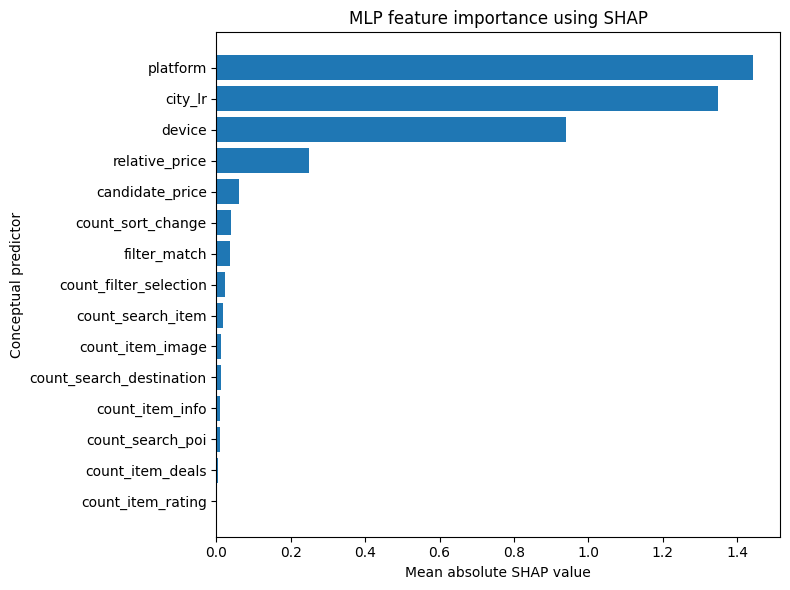

In [ ]:
# Plot conceptual MLP SHAP importance

import matplotlib.pyplot as plt

plot_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Conceptual predictor")
plt.title("MLP feature importance using SHAP")

plt.tight_layout()
plt.show()

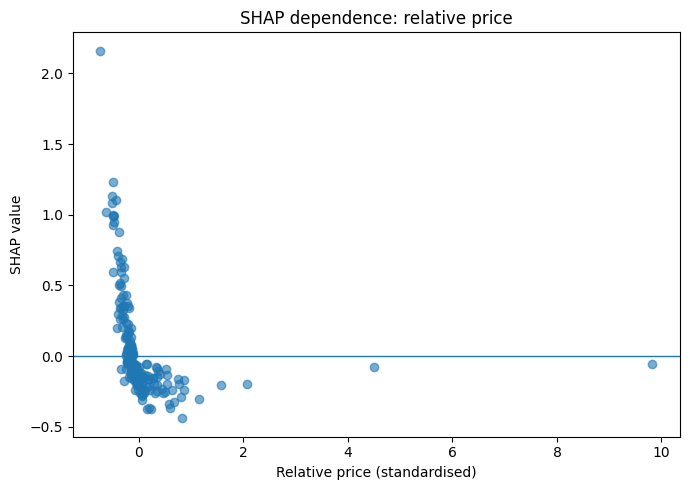

In [ ]:
# Plot SHAP dependence for relative price

relative_price_idx = feature_names.index("relative_price")

relative_price_values = X_shap_explain_dense[:, relative_price_idx]
relative_price_shap = shap_values[:, relative_price_idx]

plt.figure(figsize=(7, 5))

plt.scatter(
    relative_price_values,
    relative_price_shap,
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.xlabel("Relative price (standardised)")
plt.ylabel("SHAP value")
plt.title("SHAP dependence: relative price")

plt.tight_layout()
plt.show()

The plot above shows the non-linear relationship between Relative Price and the target. This is interesting, as this relatiobship was not visible in the Linear Regression model when I ran the coefficient check (to include in the report).

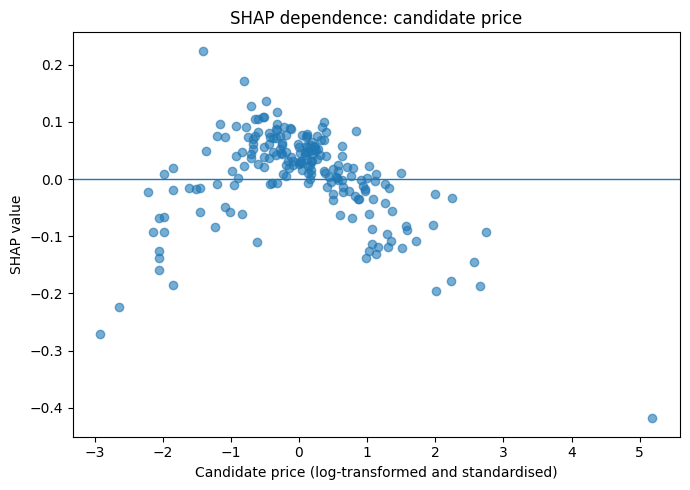

In [ ]:
# Plot SHAP dependence for candidate price

candidate_price_idx = feature_names.index("candidate_price")

candidate_price_values = X_shap_explain_dense[:, candidate_price_idx]
candidate_price_shap = shap_values[:, candidate_price_idx]

plt.figure(figsize=(7, 5))

plt.scatter(
    candidate_price_values,
    candidate_price_shap,
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.xlabel("Candidate price (log-transformed and standardised)")
plt.ylabel("SHAP value")
plt.title("SHAP dependence: candidate price")

plt.tight_layout()
plt.show()

# 5. Presentation demonstration: tuned MLP ranking one test event

In [ ]:
# Presentation demonstration: tuned MLP ranking one test event

import pandas as pd
import numpy as np
import joblib
import torch
import torch.nn as nn
from IPython.display import display

# ---------------------------------------------------------
# 1. Load untouched test data
# ---------------------------------------------------------

test_data = pd.read_parquet(
    f"{DATA_PATH}/test_preprocessed.parquet"
)

print(
    f"Untouched test set loaded: "
    f"{test_data['ranking_event_id'].nunique():,} ranking events"
)


# ---------------------------------------------------------
# 2. Load the fitted preprocessing pipeline
# ---------------------------------------------------------

mlp_preprocessor = joblib.load(
    f"{DATA_PATH}/logistic_regression_preprocessor.joblib"
)

behavioural_features = [
    "count_sort_change",
    "count_filter_selection",
    "count_item_deals",
    "count_item_image",
    "count_item_info",
    "count_item_rating",
    "count_search_destination",
    "count_search_item",
    "count_search_poi"
]

mlp_features = [
    "candidate_price",
    "relative_price",
    "filter_match",
    "city_lr",
    "platform",
    "device"
] + behavioural_features


# ---------------------------------------------------------
# 3. Define and load the final tuned MLP
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu"):
        super().__init__()

        activation_functions = {
            "relu": nn.ReLU,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }

        activation_class = activation_functions[activation]

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(
                nn.Linear(previous_dim, hidden_dim)
            )
            layers.append(
                activation_class()
            )
            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)


# Determine transformed input dimension
X_check = mlp_preprocessor.transform(
    test_data[mlp_features].iloc[:1]
)

input_dim = X_check.shape[1]

final_mlp_model = MLP(
    input_dim=input_dim,
    hidden_layers=[64, 64],
    activation="relu"
).to(device)

checkpoint = torch.load(
    f"{DATA_PATH}/mlp_64_64_lr_0001_checkpoint.pt",
    map_location=device,
    weights_only=True
)

final_mlp_model.load_state_dict(checkpoint)
final_mlp_model.eval()

print(
    f"Final tuned MLP loaded: "
    f"{input_dim} → 64 → 64 → 1"
)


# ---------------------------------------------------------
# 4. Find a suitable test event for the demonstration
# ---------------------------------------------------------

# For presentation purposes, select an event where:
# - there are 10–20 candidates, so the table is readable
# - exactly one candidate was clicked
# - the clicked candidate is ranked 2–5 by the MLP
#
# This is deliberately selected for demonstration clarity.
# Overall model performance is reported separately using
# the complete untouched test set.

event_sizes = (
    test_data
    .groupby("ranking_event_id")
    .size()
)

eligible_event_ids = event_sizes[
    (event_sizes >= 10) &
    (event_sizes <= 20)
].index

# Reproducible ordering
rng = np.random.default_rng(42)
eligible_event_ids = rng.permutation(
    eligible_event_ids.to_numpy()
)

selected_event = None
selected_clicked_rank = None


# ---------------------------------------------------------
# 5. Score candidate events until a suitable example is found
# ---------------------------------------------------------

for event_id in eligible_event_ids:

    event = (
        test_data.loc[
            test_data["ranking_event_id"] == event_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Keep only events with exactly one observed clicked candidate
    if event["clicked"].sum() != 1:
        continue

    # Apply the SAME fitted preprocessing pipeline used by the model
    X_event = mlp_preprocessor.transform(
        event[mlp_features]
    )

    if hasattr(X_event, "toarray"):
        X_event = X_event.toarray()

    X_event_tensor = torch.tensor(
        X_event,
        dtype=torch.float32,
        device=device
    )

    # Generate candidate scores
    with torch.no_grad():

        logits = final_mlp_model(
            X_event_tensor
        )

        scores = (
            torch.sigmoid(logits)
            .squeeze(1)
            .cpu()
            .numpy()
        )

    event["MLP_score"] = scores

    # Convert scores into ranks
    event["MLP_rank"] = (
        event["MLP_score"]
        .rank(
            method="first",
            ascending=False
        )
        .astype(int)
    )

    clicked_rank = int(
        event.loc[
            event["clicked"] == 1,
            "MLP_rank"
        ].iloc[0]
    )

    # Select an event where the clicked candidate
    # appears near the top, but not necessarily first
    if 2 <= clicked_rank <= 5:

        selected_event = event.copy()
        selected_clicked_rank = clicked_rank
        break


# ---------------------------------------------------------
# 6. Check that an event was found
# ---------------------------------------------------------

if selected_event is None:
    raise ValueError(
        "No suitable ranking event was found. "
        "Try widening the desired clicked-candidate rank range."
    )

demo_event = selected_event

clicked_candidate = demo_event.loc[
    demo_event["clicked"] == 1,
    "candidate_id"
].iloc[0]

print()
print("DEMONSTRATION RANKING EVENT")
print("---------------------------")
print("Ranking event:", demo_event["ranking_event_id"].iloc[0])
print("Number of candidates:", len(demo_event))
print("Actually clicked candidate:", clicked_candidate)
print("MLP rank of clicked candidate:", selected_clicked_rank)


# ---------------------------------------------------------
# 7. Create clean presentation output
# ---------------------------------------------------------

demo_output = demo_event[
    [
        "candidate_id",
        "candidate_position",
        "MLP_score",
        "MLP_rank",
        "clicked"
    ]
].copy()

demo_output = (
    demo_output
    .sort_values("MLP_rank")
    .reset_index(drop=True)
)

demo_output = demo_output.rename(
    columns={
        "candidate_id": "Candidate",
        "candidate_position": "Trivago rank",
        "MLP_score": "MLP score",
        "MLP_rank": "MLP rank",
        "clicked": "Actually clicked"
    }
)

demo_output["MLP score"] = (
    demo_output["MLP score"]
    .round(4)
)


# ---------------------------------------------------------
# 8. Display the MLP ranking
# ---------------------------------------------------------

print()
print("MLP PREDICTED RANKING")
print("---------------------")

display(
    demo_output.style.apply(
        lambda row: [
            "font-weight: bold; background-color: #ffffcc"
            if row["Actually clicked"] == 1
            else ""
            for _ in row
        ],
        axis=1
    )
)


# ---------------------------------------------------------
# 9. Show the result for the clicked candidate
# ---------------------------------------------------------

clicked_result = demo_output.loc[
    demo_output["Actually clicked"] == 1
].iloc[0]

print()
print("RESULT FOR ACTUALLY CLICKED CANDIDATE")
print("-------------------------------------")
print("Candidate:", clicked_result["Candidate"])
print("Trivago original rank:", clicked_result["Trivago rank"])
print("MLP predicted rank:", clicked_result["MLP rank"])
print("MLP score:", clicked_result["MLP score"])


# ---------------------------------------------------------
# 10. Presentation note
# ---------------------------------------------------------

print()
print(
    "Presentation note: This test event was deliberately selected "
    "because the clicked candidate appears within MLP ranks 2–5, "
    "making the scoring and ranking process easier to demonstrate. "
    "Overall model performance is evaluated separately across the "
    "complete untouched test set."
)

Untouched test set loaded: 23,273 ranking events
Final tuned MLP loaded: 5175 → 64 → 64 → 1

DEMONSTRATION RANKING EVENT
---------------------------
Ranking event: 69694ab6edd99_2
Number of candidates: 13
Actually clicked candidate: 995309
MLP rank of clicked candidate: 5

MLP PREDICTED RANKING
---------------------


,Candidate,Trivago rank,MLP score,MLP rank,Actually clicked
0,9510604,13,0.060900,1,0
1,563106,8,0.057200,2,0
2,1109262,4,0.056600,3,0
3,60243,12,0.056100,4,0
4,995309,1,0.054500,5,1
5,562221,5,0.054500,6,0
6,1365447,7,0.052600,7,0
7,1320567,2,0.050800,8,0
8,1827625,9,0.050800,9,0
9,1930099,6,0.049800,10,0



RESULT FOR ACTUALLY CLICKED CANDIDATE
-------------------------------------
Candidate: 995309
Trivago original rank: 1
MLP predicted rank: 5
MLP score: 0.0545

Presentation note: This test event was deliberately selected because the clicked candidate appears within MLP ranks 2–5, making the scoring and ranking process easier to demonstrate. Overall model performance is evaluated separately across the complete untouched test set.
